# Module 11 — Decision Trees
## Structure · Entropy · Gini · Information Gain · Pruning · Evaluation · ROC-AUC
---
> Decision Tree হলো ML-এর সবচেয়ে **interpretable** model।
> এটা বোঝা মানে **Random Forest** ও **XGBoost**-এর foundation বোঝা।
> এই module-এ theory + code + evaluation সবকিছু একসাথে শেখা হবে।

| Section | Topic |
|---|---|
| 11.1 | Introduction — কেন Decision Tree? |
| 11.2 | Tree Structure — Root, Internal, Leaf, Branch |
| 11.3 | Entropy, Gini Index, Information Gain |
| 11.4 | Synthetic Data দিয়ে Tree তৈরি |
| 11.5 | Overfitting ও Pruning |
| 11.6-7 | Accuracy, Precision, Recall, F1, Confusion Matrix |
| 11.8-9 | ROC Curve, AUC, Threshold |
| 11.10 | Conclusion |


---
## Setup — Libraries


In [107]:
# Now we import all libraries needed for this module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("All libraries imported!")

All libraries imported!


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library import করা হয়েছে। `sklearn.tree`, `sklearn.metrics` — এই module-এর মূল tools।

---
## 11.1 Introduction — কেন Decision Tree শিখব?

### Real-life Analogy (PDF Slide থেকে)
> ডাক্তার রোগী দেখার সময় প্রশ্ন করেন:
> *'বয়স ৩০-এর কম?'* → হ্যাঁ → *'অনেক পিৎজা খাও?'* → হ্যাঁ → **Unfit!**
> *'বয়স ৩০-এর বেশি?'* → *'সকালে exercise করো?'* → হ্যাঁ → **Fit!**
> এই if-else প্রশ্নের chain-ই Decision Tree।

### Decision Tree কেন গুরুত্বপূর্ণ? (PDF থেকে)

| বৈশিষ্ট্য | বিস্তারিত |
|---|---|
| **Simple & Intuitive** | মানুষ যেভাবে সিদ্ধান্ত নেয় সেভাবে কাজ করে |
| **Easy to Visualize** | Flowchart-এর মতো দেখানো যায়, non-technical stakeholder বোঝে |
| **Versatile Data Handling** | Numeric ও categorical দুটোই handle করে |
| **Minimal Preprocessing** | Feature scaling দরকার নেই |
| **Non-linear Patterns** | Complex, non-linear relationship ধরতে পারে |
| **Excellent Baseline** | Quick to train — baseline model হিসেবে perfect |

### Decision Tree কেন শিখব?
```
Decision Tree বুঝলে বুঝতে পারবে:
  Random Forest    -> অনেক Decision Tree একসাথে (Ensemble)
  XGBoost          -> Decision Tree chain করা (Boosting)
  Feature Importance -> কোন feature important সেটা tree থেকে বোঝা
```

### Linear Regression vs Decision Tree

| | Linear/Logistic Regression | Decision Tree |
|---|---|---|
| কীভাবে সিদ্ধান্ত | Mathematical equation (wx+b) | If-else rules |
| Non-linear pattern | ধরতে পারে না | পারে |
| Feature Scaling | দরকার | **দরকার নেই** |
| Interpretability | Medium | **Very High** |
| Overfitting ঝুঁকি | কম | বেশি (Pruning দরকার) |

### 🎯 Interview Topics
- Decision Tree scale-invariant কেন? → Split করার সময় শুধু order দেখে, actual value নয়
- Decision Tree কি regression-এ ব্যবহার হয়? → হ্যাঁ, `DecisionTreeRegressor` আছে
- সবচেয়ে বড় weakness? → Overfitting — training data memorize করে
- High variance মানে কী? → Training data একটু বদলালে সম্পূর্ণ আলাদা tree হয়


---
## 11.2 Decision Tree Structure

**Tree** হলো পুরো structure — একটার পর একটা **প্রশ্ন করতে করতে** সিদ্ধান্তে পৌঁছায়।

**Node** হলো সেই প্রতিটি **প্রশ্নের জায়গা**।
- **Root Node** → প্রথম প্রশ্ন (সবচেয়ে গুরুত্বপূর্ণ)
- **Internal Node** → মাঝের প্রশ্নগুলো
- **Leaf Node** → শেষ উত্তর (আর প্রশ্ন নেই)


### Tree-এর Anatomy (PDF Slide থেকে)
```
            [Root Node]         <- সবচেয়ে উপরে, সবচেয়ে important split
           Age < 30?
          /         \
        Yes           No
         |             |
  [Internal Node]  [Internal Node]
  Pizza খাও?      Morning Exercise?
    /    \            /      \
  Yes    No         Yes      No
   |      |          |        |
[Leaf] [Leaf]    [Leaf]    [Leaf]
Unfit   Fit       Fit      Unfit   <- Leaf Node-এ final prediction
```

### চারটি Component (PDF Slide থেকে)

| Component | মানে | Role |
|---|---|---|
| **Root Node** | সবচেয়ে উপরের node | সবচেয়ে important split — সব data এখান দিয়ে যায় |
| **Internal Node** | মাঝখানের node | আরো প্রশ্ন করে data আরো ভাগ করে |
| **Branch** | দুটো node-এর connection | condition-এর answer (Yes/No, True/False) |
| **Leaf Node** | শেষ node | Final prediction — majority class বা mean value |

### Tree কীভাবে Split বেছে নেয়?
> প্রতিটি node-এ সেই feature ও threshold বেছে নেওয়া হয় যেটায়
> split করলে দুটো group **সবচেয়ে pure** হয়।

## ✂️ Split ও Threshold
**Split** মানে data-কে **দুই ভাগে ভাগ করা**।
**Threshold** হলো সেই **কাটার রেখা**।
> উদাহরণ: "Age > 30?" — এখানে **30 হলো threshold**। এর উপরে এক দল, নিচে আরেক দল।


**Pure group** = একটি class-ই বেশি আছে → confident prediction সম্ভব
**Impure group** = 50-50 mixed → কোনো confident prediction নয়

### Impurity-র তিনটি Level (PDF থেকে)
| Group | Content | Purity |
|---|---|---|
| Group A | 10 Yes, 0 No | **Perfect Pure** — Entropy=0, Gini=0 |
| Group B | 5 Yes, 5 No | **Maximum Impure** — Entropy=1, Gini=0.5 |
| Group C | 8 Yes, 2 No | **Moderate Pure** — between A and B |


## 🎯 Pure vs Impure Group

| Group | অর্থ | উদাহরণ |
|---|---|---|
| **Perfect Pure** | সবাই একই class | ১০ জনের মধ্যে ১০ জনই "হ্যাঁ" |
| **Moderate Pure** | বেশিরভাগ একই class | ১০ জনের মধ্যে ৭ জন "হ্যাঁ" |
| **Maximum Impure** | ঠিক অর্ধেক অর্ধেক | ১০ জনের মধ্যে ৫ জন "হ্যাঁ", ৫ জন "না" |

> 💡 Tree সবসময় **সবচেয়ে pure group** তৈরি করে এমন split খোঁজে।

## 🚨 Overfitting

Tree যদি **অনেক বেশি গভীর** হয় — সে training data **মুখস্থ** করে ফেলে।
নতুন data দিলে **ভুল করে** — কারণ সে শুধু পুরনো pattern চেনে।
> ⚠️ এটাই **Overfitting** — Training-এ 100%, Test-এ খারাপ।
**সমাধান:** Tree-র depth **সীমিত** রাখো।

### 🎯 Interview Topics
- Root node কোন feature পায়? → সবচেয়ে বেশি Information Gain দেওয়া feature
- Leaf node-এ কী থাকে? → Majority class (classification) বা mean (regression)
- Depth বাড়ালে? → Model complex হয়, overfitting ঝুঁকি বাড়ে
- Tree-এর prediction path trace করো → Root থেকে leaf পর্যন্ত যে branch follow করে


In [108]:
# Now we create the cricket dataset from the PDF slide
# Weather (Sunny/Rainy) and Windy (0/1) -> Play? (1/0)

cricket_data = {
    "Weather": ["Sunny", "Rainy", "Sunny", "Sunny", "Rainy", "Rainy", "Sunny", "Rainy"],
    "Windy":   [0,       1,       0,       1,       0,       1,       0,       1],
    "Play":    [1,       0,       1,       1,       0,       0,       1,       0]
}

cricket_dataframe = pd.DataFrame(cricket_data)
print("Cricket Dataset (from PDF slide):")
print(cricket_dataframe)
print()

print("The Decision Rule:")
print("  If Weather = Sunny -> Play Cricket (1)")
print("  If Weather = Rainy -> Don't Play (0)")

Cricket Dataset (from PDF slide):
  Weather  Windy  Play
0   Sunny      0     1
1   Rainy      1     0
2   Sunny      0     1
3   Sunny      1     1
4   Rainy      0     0
5   Rainy      1     0
6   Sunny      0     1
7   Rainy      1     0

The Decision Rule:
  If Weather = Sunny -> Play Cricket (1)
  If Weather = Rainy -> Don't Play (0)


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর exact cricket dataset তৈরি করা হয়েছে। এই simple dataset দিয়ে decision tree-এর basic concept বোঝানো হবে।

In [109]:
# Now we encode categorical feature and train the tree (module notebook exact code)

cricket_dataframe["Weather_num"] = cricket_dataframe["Weather"].map({"Sunny": 1, "Rainy": 0})
# Explanation: We are converting the text data in 'Weather' into numbers using '.map()'. Machine Learning models cannot understand words like "Sunny", so we change them to 1 and 0.
# বাংলা ব্যাখ্যা: 'Weather' কলামের কথাগুলোকে আমরা '.map()' দিয়ে সংখ্যায় রূপান্তর করছি। মেশিন লার্নিং মডেল "Sunny" বা "Rainy" সরাসরি বোঝে না, তাই সেগুলোকে ১ এবং ০ বানিয়ে দেওয়া হয়েছে।


X_cricket = cricket_dataframe[["Weather_num", "Windy"]]
y_cricket  = cricket_dataframe["Play"]
# Explanation: We are splitting the data into two parts. 'X_cricket' contains the input features (Weather and Wind) used to make a decision, and 'y_cricket' contains the target or result (whether they played or not).
# বাংলা ব্যাখ্যা: আমরা ডেটাকে দুই ভাগে ভাগ করছি। 'X_cricket' এ আছে ইনপুট বা বৈশিষ্ট্য (আবহাওয়া এবং বাতাস) যা দেখে সিদ্ধান্ত নেওয়া হবে, আর 'y_cricket' এ আছে মূল ফলাফল (খেলা হয়েছে কি হয়নি)।


# Train decision tree
cricket_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
cricket_tree.fit(X_cricket, y_cricket)
# Explanation: First, we create the model 'DecisionTreeClassifier' with a 'max_depth' of 3 (meaning the tree can only have 3 levels). Then, we use '.fit()' to let the model learn from our 'X' and 'y' data.
# বাংলা ব্যাখ্যা: প্রথমে আমরা 'DecisionTreeClassifier' মডেলটি তৈরি করছি যেখানে 'max_depth' দেওয়া হয়েছে ৩ (তারমানে গাছটি ৩ লেভেলের বেশি বড় হবে না)। এরপর '.fit()' ব্যবহার করে মডেলটিকে আমাদের ডেটা থেকে শেখানো (Train করা) হচ্ছে।


print("Tree trained!")
print()
print("Tree Rules (text format):")
print(export_text(cricket_tree, feature_names=["Weather_num", "Windy"]))
# Explanation: We are using 'export_text' to print out the internal logic or "rules" the tree learned. This shows exactly how the model makes decisions based on 'Weather_num' and 'Windy'.
# বাংলা ব্যাখ্যা: গাছটি ভেতর ভেতর কী কী নিয়ম বা "Rules" শিখলো তা আমরা 'export_text' দিয়ে প্রিন্ট করছি। এর ফলে আমরা দেখতে পাবো ঠিক কোন কোন শর্তের ওপর ভিত্তি করে মডেলটি সিদ্ধান্ত নিচ্ছে।

Tree trained!

Tree Rules (text format):
|--- Weather_num <= 0.50
|   |--- class: 0
|--- Weather_num >  0.50
|   |--- class: 1



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact code। `map({'Sunny':1,'Rainy':0})` categorical-কে numeric-এ convert করে। `export_text()` tree-এর if-else rules text হিসেবে দেখায়।

`max_depth` ফিচারের সংখ্যার সাথে সরাসরি সম্পর্কিত নয়। ৩টি ফিচার থাকলে যে `max_depth` ৩ দিতে হবে, এমন কোনো নিয়ম নেই।

নিচে সহজভাবে বুঝিয়ে বলছি এটি কীভাবে কাজ করে এবং কীভাবে সিলেক্ট করবে:

### ১. `max_depth` আসলে কী?
এটি হলো গাছের **"লম্বা"** হওয়ার সীমা। একটি বীজের থেকে অঙ্কুর গজানোর পর সেটি কত তলা পর্যন্ত ডালপালা মেলতে পারবে, এটি মূলত সেটিই ঠিক করে দেয়।
* `max_depth=3` মানে হলো গাছটি সর্বোচ্চ ৩ বার প্রশ্ন করে নিচে নামতে পারবে।

### ২. এটি সিলেক্ট করার নিয়ম (কিভাবে বুঝবে কত দিবে?)

এটি মূলত নির্ভর করে তোমার ডেটার **Complexity** বা জটিলতার ওপর। এটি সিলেক্ট করার সময় দুটি জিনিস মাথায় রাখতে হয়:
* **খুব ছোট দিলে (Underfitting):** যদি তোমার ডেটা অনেক বড় হয় কিন্তু তুমি `max_depth=2` দাও, তবে গাছটি সব তথ্য শেখার আগেই থেমে যাবে। এতে মডেলের একুরেসি কমে যাবে।
* **খুব বড় দিলে (Overfitting):** যদি তুমি `max_depth` অনেক বেশি দাও (যেমন ১০০), তবে গাছটি ডেটার ভেতরকার অপ্রয়োজনীয় খুঁটিনাটি (Noise) মুখস্থ করে ফেলবে। এতে সে তোমার ট্রেইনিং ডেটায় ১০০% রেজাল্ট দিলেও নতুন ডেটা দিলে ফেইল করবে।

### ৩. তাহলে সঠিক সংখ্যাটি কীভাবে পাবে?

বাস্তবে এটি সিলেক্ট করার জন্য নিচের পদ্ধতিগুলো ব্যবহার করা হয়:
* **Trial and Error:** প্রথমে ছোট সংখ্যা (যেমন ৩ বা ৫) দিয়ে শুরু করে দেখা হয় রেজাল্ট কেমন আসছে।
* **Cross-Validation:** বিভিন্ন ডেপথ (৩, ৫, ৭, ১০) দিয়ে টেস্ট করে দেখা হয় কোনটিতে সবথেকে ভালো রেজাল্ট পাওয়া যাচ্ছে।
* **Default:** অনেক সময় আমরা এটি ফাঁকা রাখি, তখন গাছটি যতক্ষণ না পর্যন্ত ডেটা পুরোপুরি "Pure" হচ্ছে ততক্ষণ পর্যন্ত বাড়তে থাকে। তবে বড় ডেটাসেটে এটি রিস্কি।

### ৪. ফিচারের সাথে কি কোনো সম্পর্ক আছে?
সরাসরি সম্পর্ক না থাকলেও একটি মজার বিষয় আছে। তোমার যদি মাত্র ২টি ফিচার থাকে (যেমন: আবহাওয়া আর বাতাস), আর তুমি `max_depth=10` দিয়ে দাও, তবে গাছটি একই ফিচার বারবার ব্যবহার করে ভাগ করতে থাকবে (যেমন: বাতাসের গতি কি ১০? তারপর আবার জিজ্ঞেস করবে বাতাসের গতি কি ১২?)। এতে মডেলটি অনেক বেশি জটিল হয়ে যায় যা সাধারণত ভালো নয়।

**সারকথা:** তোমার ডেটা যদি খুব সিম্পল হয়, তবে **৩ থেকে ৫** এর মধ্যে রাখা ভালো। আর ডেটা যদি অনেক বেশি বড় এবং জটিল হয়, তখন বড় সংখ্যা ট্রাই করতে পারো।

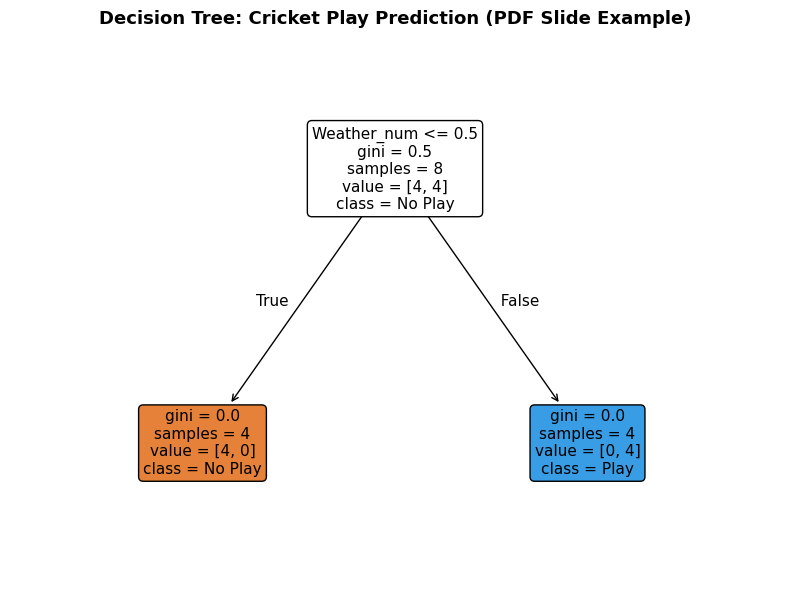

In [110]:
# Now we visualize the decision tree diagram (module notebook exact code)

plt.figure(figsize=(8, 6))
# Explanation: We are setting the size of the drawing area. 'figsize=(8, 6)' means the plot will be 8 inches wide and 6 inches tall, so the tree diagram looks clear and not squeezed.
# বাংলা ব্যাখ্যা: আমরা ছবি বা ডায়াগ্রামটির সাইজ ঠিক করছি। 'figsize=(8, 6)' দিয়ে বোঝানো হয়েছে ছবিটি চওড়ায় ৮ ইঞ্চি এবং লম্বায় ৬ ইঞ্চি হবে, যাতে গাছের ডায়াগ্রামটি পরিষ্কার দেখা যায়।


plot_tree(
    cricket_tree,
    feature_names=["Weather_num", "Windy"],
    class_names=["No Play", "Play"],
    filled=True,
    rounded=True,
    fontsize=11
)
# Explanation: This is the main command to draw the tree. We give it our trained model 'cricket_tree'. 'feature_names' labels the branches, 'class_names' labels the final results, 'filled=True' adds colors to the boxes, and 'rounded=True' makes the corners of the boxes smooth.
# বাংলা ব্যাখ্যা: এটিই গাছটি আঁকার আসল কমান্ড। আমরা আমাদের তৈরি করা 'cricket_tree' মডেলটি এখানে দিচ্ছি। 'feature_names' দিয়ে ডালপালার নাম এবং 'class_names' দিয়ে শেষ ফলাফলগুলোর নাম লেবেল করা হচ্ছে। 'filled=True' দিলে বক্সগুলোতে রঙ হবে এবং 'rounded=True' দিলে বক্সের কোণাগুলো গোল হবে।


plt.title("Decision Tree: Cricket Play Prediction (PDF Slide Example)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: We are adding a bold title to the top of the chart using 'plt.title'. 'plt.tight_layout()' automatically adjusts the spacing so nothing gets cut off, and 'plt.show()' finally displays the window with our complete diagram.
# বাংলা ব্যাখ্যা: 'plt.title' ব্যবহার করে আমরা চার্টের উপরে একটি বোল্ড শিরোনাম দিচ্ছি। 'plt.tight_layout()' চার্টের চারপাশের জায়গাগুলো নিজে থেকেই ঠিক করে নেয় যাতে কোনো কিছু কেটে না যায়, আর 'plt.show()' শেষ পর্যন্ত আমাদের পুরো ডায়াগ্রামটি স্ক্রিনে দেখায়।

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `plot_tree()` code। `filled=True` দিলে class অনুযায়ী রঙ হয়। Orange = Play (1), Blue = No Play (0)। গাঢ় রঙ = বেশি pure node।

> ### এই chart কীভাবে observe করব

এখন ডায়াগ্রামের প্রতিটি শব্দের সহজ মানে বুঝে নিই:

### ১. Samples (নমুনা)
ঐ বক্সে বা নোডে কতগুলো ডেটা পয়েন্ট আছে। একদম শুরুতে তোমার কাছে মোট **৮টি** ডেটা ছিল, তাই প্রথম বক্সে `samples = 8` লেখা।

### ২. Value (মান)
এটি মূলত ক্লাসের সংখ্যা দেখায়। শুরুতে `value = [4, 4]` মানে হলো— ৪ জন 'না' (No Play) এবং ৪ জন 'হ্যাঁ' (Play) ক্লাসের মানুষ আছে।

### ৩. Gini (অপরিচ্ছন্নতা)
গিনি হলো "জগাখিচুড়ি" মাপার স্কেল।
* যদি বক্সে লাল-নীল সব মিশে থাকে, তবে **Gini = 0.5** (অপরিচ্ছন্ন)।
* যদি বক্সে শুধু এক ধরণের ডেটা থাকে, তবে **Gini = 0.0** (একেবারে পরিষ্কার বা Pure)।

### ৪. কিভাবে Split (ভাগ) হলো?
মডেল দেখলো তার কাছে দুটি প্রশ্ন আছে: 'আবহাওয়া কেমন?' এবং 'বাতাস আছে কি?'। সে দেখলো যদি সে 'Weather_num <= 0.5' (অর্থাৎ বৃষ্টি হচ্ছে কি না) প্রশ্নটি করে, তবে ডেটা একদম পরিষ্কার দুই ভাগে ভাগ হয়ে যায়।

**বক্সটি কেন বিভক্ত হলো?**
* **বাম দিকে (True):** যাদের আবহাওয়া ০.৫ এর কম (অর্থাৎ বৃষ্টি হচ্ছিল)।
* **ডান দিকে (False):** যাদের আবহাওয়া ০.৫ এর বেশি (অর্থাৎ রোদ ছিল)।

### ৫. Orange Leaf এবং Blue Leaf এর Values কীভাবে আসলো?

**Orange Leaf (বাম দিকের বক্স):**
মডেল দেখলো ঐ ৮ জনের মধ্যে ৪ জন এমন ছিল যাদের সময় বৃষ্টি হচ্ছিল। মজার ব্যাপার হলো, ঐ ৪ জনের কেউই কিন্তু ক্রিকেট খেলেনি!
* তাই এখানে `samples = 4` এবং `value = [4, 0]` (৪ জন 'না', ০ জন 'হ্যাঁ')।
* যেহেতু সবাই এক ক্লাসের (সবাই 'No Play'), তাই এর **Gini = 0.0**। এটি একদম "পরিষ্কার" বা Pure সিদ্ধান্ত।

**Blue Leaf (ডান দিকের বক্স):**
বাকি ৪ জন এমন ছিল যাদের সময় রোদ ছিল। তারা সবাই ক্রিকেট খেলেছে।
* তাই এখানে `samples = 4` এবং `value = [0, 4]` (০ জন 'না', ৪ জন 'হ্যাঁ')।
* এখানেও সবাই এক জাতের, তাই **Gini = 0.0**।

### সারকথা:
গাছটি এমন একটি প্রশ্ন খুঁজে বের করেছে যাতে এক এক দিকে শুধু একই ধরণের রেজাল্ট জমা হয়। যখনই সে রেজাল্ট ১০০% পিওর (**Gini = 0**) পেয়ে গেছে, তখন সে আর নিচে নামেনি বা গাছটিকে আর বড় করেনি।


In [111]:
# Now we make predictions on new examples (module notebook exact code)

# Example 1: Sunny (1), not windy (0)
example_one = pd.DataFrame([[1, 0]], columns=["Weather_num", "Windy"])
prediction_one = cricket_tree.predict(example_one)[0]
print(f"Example One DataFrame:")
print(example_one)
print(f"Sunny, not windy -> Play prediction: {prediction_one} ({'Play' if prediction_one==1 else 'No Play'})")
print()
# Explanation: We are creating a new data point called 'example_one' where the weather is Sunny (1) and it is not windy (0). Then, we use '.predict()' to ask the model for its decision. Finally, we print whether the result is 1 (Play) or 0 (No Play).
# বাংলা ব্যাখ্যা: আমরা 'example_one' নামে একটি নতুন ডেটা তৈরি করছি যেখানে রোদ আছে (1) এবং বাতাস নেই (0)। এরপর আমরা '.predict()' ব্যবহার করে মডেলটিকে জিজ্ঞেস করছি তার সিদ্ধান্ত কী। শেষে আমরা প্রিন্ট করছি ফলাফল কি ১ (খেলবে) নাকি ০ (খেলবে না)।


# Example 2: Rainy (0), windy (1)
example_two = pd.DataFrame([[0, 1]], columns=["Weather_num", "Windy"])
prediction_two = cricket_tree.predict(example_two)[0]
print(f"Example Two DataFrame:")
print(example_two)
print(f"Rainy, windy     -> Play prediction: {prediction_two} ({'Play' if prediction_two==1 else 'No Play'})")
print()
# Explanation: We are testing another scenario: Rainy (0) and Windy (1). The model looks at the 'Weather_num' column first because that's what it learned from the tree. Even though it is windy, the model makes a prediction based on the rules it learned during training.
# বাংলা ব্যাখ্যা: আমরা দ্বিতীয় একটি পরিস্থিতি টেস্ট করছি: বৃষ্টি (0) এবং বাতাস (1)। মডেলটি প্রথমে 'Weather_num' কলামের দিকে তাকাবে কারণ সে গাছ থেকে এটাই শিখেছে। বাতাস থাকলেও মডেলটি ট্রেইনিংয়ের সময় শেখা নিয়ম অনুযায়ী তার সিদ্ধান্ত বা প্রেডিকশন দিচ্ছে।


# Example 3: Rainy (0), not windy (0)
example_three = pd.DataFrame([[0, 0]], columns=["Weather_num", "Windy"])
prediction_three = cricket_tree.predict(example_three)[0]
print(f"Example Three DataFrame:")
print(example_three)
print(f"Rainy, not windy -> Play prediction: {prediction_three} ({'Play' if prediction_three==1 else 'No Play'})")
print()
# Explanation: In this third example, it is Rainy (0) but not windy (0). The model uses '.predict()' again. Based on our earlier tree diagram, we know that if it's Rainy (Weather_num <= 0.5), the model will always predict 0 (No Play), regardless of the wind.
# বাংলা ব্যাখ্যা: এই তৃতীয় উদাহরণে বৃষ্টি আছে (0) কিন্তু বাতাস নেই (0)। মডেলটি আবারও '.predict()' ফাংশনটি ব্যবহার করছে। আমাদের আগের ট্রি ডায়াগ্রাম অনুযায়ী আমরা জানি যে যদি বৃষ্টি থাকে (Weather_num <= 0.5), তবে বাতাস থাকুক বা না থাকুক, মডেলটি সবসময় ০ (খেলবে না) প্রেডিক্ট করবে।

Example One DataFrame:
   Weather_num  Windy
0            1      0
Sunny, not windy -> Play prediction: 1 (Play)

Example Two DataFrame:
   Weather_num  Windy
0            0      1
Rainy, windy     -> Play prediction: 0 (No Play)

Example Three DataFrame:
   Weather_num  Windy
0            0      0
Rainy, not windy -> Play prediction: 0 (No Play)



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact prediction examples। নতুন data point দিলে tree root থেকে leaf পর্যন্ত path follow করে prediction দেয়।

## 11.3 Entropy, Gini Index, এবং Information Gain

### Entropy — Disorder মাপার tool
> **Entropy** = physics ও information theory থেকে borrowed। একটি group-এ কতটা **disorder** বা **uncertainty** আছে সেটা measure করে। মেশিন লার্নিং বা ডিসিশন ট্রি-তে আমরা এনট্রপি ব্যবহার করি এটা বুঝতে যে আমাদের ডেটা কতটা অগোছালো বা এলোমেলো অবস্থায় আছে।
$$H = -\sum_{i} p_i \log_2(p_i)$$

| Entropy Value | মানে | Group |
|---|---|---|
| **0** | Perfect pure | 10 Yes, 0 No — certainty সর্বোচ্চ |
| **1** | Maximum impure | 5 Yes, 5 No — uncertainty সর্বোচ্চ |
| **0 < H < 1** | Moderate | 8 Yes, 2 No — কিছুটা predictable |

**Intuition:**
- High Entropy = messy, mixed group → tree এটা avoid করতে চায়
- Low Entropy = clean, pure group → tree এটাই তৈরি করতে চায়

### মেশিন লার্নিংয়ে এর কাজ কী?
ডিসিশন ট্রি যখন ডেটা ভাগ (Split) করে, সে সবসময় চায় **Entropy কমাতে**।
* শুরুতে তোমার ডেটা অনেক অগোছালো থাকে (হাই এনট্রপি)।
* গাছটি এমনভাবে প্রশ্ন করে যেন ভাগ হওয়ার পর এক এক দিকে একই ধরণের ডেটা চলে যায় (লো এনট্রপি)।

**সহজ সারকথা:**
* **Entropy বেশি** মানে হলো ডেটা অনেক বেশি মিশ্রিত বা কনফিউজিং।
* **Entropy কম** মানে হলো ডেটা অনেক বেশি গোছানো এবং সেখান থেকে সিদ্ধান্ত নেওয়া সহজ।


### Gini Index — Misclassification মাপার tool
> **Gini Index** = যদি randomly একটি item pick করে randomly একটি label দাও, তাহলে কতটা সম্ভাবনা আছে তুমি ভুল করবে? **Gini Index** (বা Gini Impurity) হলো এনট্রপির মতোই একটি মাপকাঠি, যা দিয়ে বোঝা যায় আমাদের ডেটা কতটা **"অপরিচ্ছন্ন"** বা **"জগাখিচুড়ি"** অবস্থায় আছে। সহজ কথায়, এটি আমাদের বলে যে একটি নির্দিষ্ট গ্রুপের ডেটা কতটা একজাতীয় (Pure)।
$$Gini = 1 - \sum_{i} p_i^2$$

| Gini Value | মানে |
|---|---|
| **0** | Pure group — ভুল করার সম্ভাবনা শূন্য |
| **0.5** | Maximum impure — ভুল করার সম্ভাবনা সর্বোচ্চ |

### ১. গিনি ইনডেক্স-এর মান (The Scale)
গিনি ইনডেক্স-এর মান সাধারণত **০ থেকে ০.৫** এর মধ্যে থাকে।
* **০ (Zero):** এর মানে হলো ডেটা একদম **Pure** বা পরিষ্কার। অর্থাৎ, একটি ঝুড়িতে শুধু এক ধরণের জিনিসই আছে (যেমন: সবগুলোই লাল বল)। এখান থেকে কিছু বেছে নিলে কোনো ভুল হওয়ার সম্ভাবনা নেই।
* **০.৫ (0.5):** এর মানে হলো ডেটা সবচেয়ে বেশি **Impure** বা জগাখিচুড়ি। অর্থাৎ, ঝুড়িতে অর্ধেক লাল আর অর্ধেক নীল বল আছে। এখানে কনফিউশন সবচেয়ে বেশি।

### ২. একটি বাস্তব উদাহরণ
মনে করো তোমার কাছে ১০ জন স্টুডেন্টের ডেটা আছে।
* **পরিস্থিতি A:** ১০ জনের সবাই পাস করেছে। এখানে কোনো ভেজাল নেই, সবাই এক জাতের। তাই এখানকার **Gini Index = 0**।
* **পরিস্থিতি B:** ৫ জন পাস করেছে আর ৫ জন ফেল করেছে। এখানে ডেটা একদম দুই ভাগে বিভক্ত এবং জগাখিচুড়ি অবস্থা। তাই এখানকার **Gini Index = 0.5**।
* **পরিস্থিতি C:** যদি ৩ জন পাস করে এবং ৭ জন ফেল করে, তবে **Gini Index = 0.42**। এখানে ডেটা কিছুটা অগোছালো, তবে পরিস্থিতি B (০.৫) এর তুলনায় কম জগাখিচুড়ি, কারণ এখানে ফেইল করা ছাত্রের সংখ্যা বা পাল্লা কিছুটা ভারী।
* **পরিস্থিতি D:** যদি ১০ জনের সবাই ফেল করে, তবে **Gini Index = 0**। কারণ এখানে কোনো ভিন্নতা নেই, সবাই একই ক্যাটাগরির (সবাই ফেইল)। তাই এটি একটি একদম **Pure** বা পরিষ্কার অবস্থা।

**সহজ টিপস:** মনে রাখবে, যখনই কোনো গ্রুপে সবাই ১০০% একই রকম হয়ে যায় (সবাই পাস বা সবাই ফেল), তখনই **Gini Index** সবসময় **০** হয়। আর যখনই মিক্সড থাকে, তখনই মান ০-এর থেকে বাড়তে থাকে।

### ৩. এনট্রপি বনাম গিনি ইনডেক্স (সহজ পার্থক্য)
তুমি হয়তো ভাবছ এনট্রপি আর গিনি তো একই কাজ করছে, তাহলে পার্থক্য কী?
* **ম্যাথমেটিক্স:** এনট্রপি ব্যবহার করে `Log` (লগারিদম), যা ক্যালকুলেট করতে কম্পিউটারের একটু বেশি সময় লাগে। আর গিনি ইনডেক্স ব্যবহার করে `Square` (বর্গ), যা অনেক দ্রুত ক্যালকুলেট করা যায়।
* **ব্যবহার:** একারণেই বড় ডেটাসেটে ডিসিশন ট্রি ট্রেইন করার সময় **Gini Index** বেশি জনপ্রিয়, কারণ এটি মডেলকে দ্রুত কাজ করতে সাহায্য করে।

### ৪. ডিসিশন ট্রি কীভাবে এটি ব্যবহার করে?
ডিসিশন ট্রি যখন ডেটাকে ভাগ (Split) করে, সে অনেকগুলো প্রশ্ন ট্রাই করে। সে সেই প্রশ্নটিকেই বেছে নেয় যেটির মাধ্যমে ভাগ করলে **Gini Index সবচেয়ে কম** হয় (অর্থাৎ ডেটা সবচেয়ে বেশি পরিষ্কার বা Pure হয়)। গিনি ইনডেক্স যত **কম**, আমাদের সিদ্ধান্ত তত বেশি **সঠিক এবং পরিষ্কার**। ডিসিশন ট্রি-র মূল লক্ষ্যই হলো ডেটাকে ভাগ করে করে গিনি ইনডেক্সকে ০-এর কাছাকাছি নিয়ে আসা।

গিনি ইনডেক্স আর এনট্রপির এই "পরিচ্ছন্নতা" মাপার ধারণাটি কি তোমার কাছে পরিষ্কার হয়েছে?

**Entropy vs Gini:**
- দুটোই same কাজ করে — impurity measure করা
- sklearn default: **Gini** (`criterion='gini'`)
- Entropy দিতে: `criterion='entropy'`
- Practice-এ দুটো result প্রায়ই একই

### Information Gain — Split কতটা ভালো সেটা মাপে
> **Information Gain** = split করার আগে ও পরে impurity-র পার্থক্য। Tree সেই split বেছে নেয় যেটায় Information Gain সবচেয়ে বেশি। **Information Gain (ইনফরমেশন গেইন)** হলো একটি লাভ-ক্ষতির হিসাব। সহজ কথায়, কোনো একটি প্রশ্ন করার আগে ডেটা কতটা অগোছালো ছিল এবং প্রশ্নটি করার পর ডেটা কতটা গোছানো হলো—এই দুইয়ের পার্থক্যকেই বলা হয় ইনফরমেশন গেইন। Decision Tree এই হিসাবটি ব্যবহার করে সিদ্ধান্ত নেয় যে কোন ফিচারটি (Feature) দিয়ে সে ডেটা ভাগ করবে।

$$IG = H_{parent} - \frac{n_{left}}{n} H_{left} - \frac{n_{right}}{n} H_{right}$$

**Simple Example (PDF Slide থেকে):**
```
Parent: 6 Yes, 4 No  -> Gini = 0.48 (impure)
           |
        Split!
       /        \
Left: 5Y, 0N    Right: 1Y, 4N
Gini = 0.00     Gini = 0.32

Information Gain = 0.48 - (5/10)*0.00 - (5/10)*0.32 = 0.32
```
Left child perfectly pure (Gini=0)! এই split excellent।


### ১. মূল আইডিয়া (The Concept)
* **আগের অবস্থা:** ডেটা যখন জগাখিচুড়ি বা অগোছালো থাকে (বেশি এনট্রপি)।
* **পরের অবস্থা:** ডেটা ভাগ করার পর যখন গোছানো হয়ে যায় (কম এনট্রপি)।
* **গেইন (Gain):** অগোছালো অবস্থা যতটুকু কমলো, সেটাই তোমার লাভ বা "Information Gain"।

### ২. একটি বাস্তব উদাহরণ
মনে করো, তুমি ঠিক করবে তুমি "বই পড়বে কি না"। তোমার কাছে ২টি তথ্য আছে: ১. লাইট আছে কি না, ২. ঘরের রঙ কী।

* **ধাপ ১:** শুরুতে তোমার পড়ার সম্ভাবনা ৫০-৫০ (অনেক অগোছালো/High Entropy)।
* **ধাপ ২ (প্রশ্ন ১ - লাইট):** তুমি দেখলে "লাইট আছে" প্রশ্নটি করলে তুমি নিশ্চিত হতে পারছো যে লাইট থাকলে পড়বে, না থাকলে পড়বে না। এখানে ডেটা একদম পরিষ্কার হয়ে গেল। অর্থাৎ, এখানে **Information Gain অনেক বেশি**।
* **ধাপ ৩ (প্রশ্ন ২ - ঘরের রঙ):** তুমি দেখলে ঘরের রঙ নীল হোক বা লাল, তা তোমার পড়ার সিদ্ধান্তে কোনো প্রভাব ফেলছে না। ডেটা আগের মতোই অগোছালো রয়ে গেল। অর্থাৎ, এখানে **Information Gain শূন্য (০)**।


### ৩. ডিসিশন ট্রি কীভাবে এটি ব্যবহার করে?
ডিসিশন ট্রি তার সবকটি ফিচারের (যেমন: Weather, Humidity, Windy) জন্য আলাদা আলাদা করে Information Gain ক্যালকুলেট করে।
> **নিয়ম:** যে ফিচারের মাধ্যমে ভাগ করলে **সবচেয়ে বেশি ইনফরমেশন গেইন** হবে (অর্থাৎ জগাখিচুড়ি অবস্থা সবথেকে বেশি কমবে), গাছটি সেই ফিচারটিকেই তার ডালপালা হিসেবে বেছে নেয়।

### ৪. গাণিতিক সূত্র (সহজভাবে)
$$Information\ Gain = Entropy(Before\ Split) - Entropy(After\ Split)$$

**সারকথা:**
ইনফরমেশন গেইন হলো একটি "ফিল্টার" এর মতো। এটি খুঁজে বের করে কোন প্রশ্নটি করলে আমরা সবথেকে পরিষ্কার উত্তর পাবো। গেইন যত বেশি হবে, ওই ফিচারটি আমাদের সিদ্ধান্তের জন্য তত বেশি গুরুত্বপূর্ণ।















### 🎯 Interview Topics
- Entropy range? → 0 (pure) to 1 (binary, maximum impure) বা log₂(k) for k classes
- Gini range? → 0 (pure) to 0.5 (binary, maximum impure)
- Entropy vs Gini কোনটা ব্যবহার করব? → Practice-এ same result, Gini computationally faster
- Information Gain maximize করা মানে? → সবচেয়ে বেশি uncertainty কমানো
- Greedy algorithm কেন? → প্রতিটি node-এ locally best split নেয়, globally optimal নাও হতে পারে


In [112]:
# Now we compute Entropy and Gini manually to understand the formulas

def compute_entropy(positive_count, negative_count):
    # Compute entropy for a binary group
    total = positive_count + negative_count
    if total == 0:
        return 0
    prob_positive = positive_count / total
    prob_negative = negative_count / total

    # Avoid log(0) -- 0 * log(0) = 0 by convention
    entropy = 0
    if prob_positive > 0:
        entropy -= prob_positive * np.log2(prob_positive)
    if prob_negative > 0:
        entropy -= prob_negative * np.log2(prob_negative)
    return entropy
# Explanation: This function 'compute_entropy' calculates how messy or "mixed" a group is. It finds the probability (percentage) of 'positive_count' and 'negative_count', then uses the 'np.log2' formula to find the entropy value. If a group is perfectly pure, it returns 0.
# বাংলা ব্যাখ্যা: 'compute_entropy' ফাংশনটি দিয়ে আমরা বের করছি একটি গ্রুপ কতটা অগোছালো। এটি 'positive_count' এবং 'negative_count' এর পার্সেন্টেজ বের করে এবং 'np.log2' (লগারিদম) সূত্র ব্যবহার করে এনট্রপির মান ক্যালকুলেট করে। যদি গ্রুপটি একদম পরিষ্কার বা একজাতীয় হয়, তবে এটি ০ রিটার্ন করে।


def compute_gini(positive_count, negative_count):
    # Compute Gini index for a binary group
    total = positive_count + negative_count
    if total == 0:
        return 0
    prob_positive = positive_count / total
    prob_negative = negative_count / total
    return 1 - (prob_positive**2 + prob_negative**2)
# Explanation: This function 'compute_gini' is a faster way to measure impurity. Instead of logs, it uses the square of probabilities ('**2'). It subtracts the squared probabilities from 1 to find the Gini Index.
# বাংলা ব্যাখ্যা: 'compute_gini' ফাংশনটি অপরিচ্ছন্নতা মাপার একটি দ্রুত পদ্ধতি। এটি লগের বদলে প্রোব্যাবিলিটির বর্গ বা 'Square' ব্যবহার করে। ১ থেকে প্রোব্যাবিলিটির বর্গের যোগফল বিয়োগ করলেই আমরা গিনি ইনডেক্স পেয়ে যাই।


# Here we test with the three groups from PDF slide
print("Group Comparisons (from PDF slide):")
print(f"{'Group':<25} {'Content':<15} {'Entropy':>10} {'Gini':>10}")
print("-" * 60)
# Explanation: We are setting up the header for a table using 'print' and string formatting like '<25' (left-align with 25 spaces). This makes the final output look organized like a real report.
# বাংলা ব্যাখ্যা: আমরা টেবিলের হেডার তৈরি করছি যেখানে 'print' এবং '<25' এর মতো ফরম্যাটিং ব্যবহার করা হয়েছে যাতে আউটপুটটি একটি রিপোর্টের মতো সুন্দর এবং গোছানো দেখায়।


groups = [
    ("Group A: Perfect Pure",   10, 0),
    ("Group B: Mostly impure",   8, 2),
    ("Group C: Max Impure",      5, 5),
    ("Group D: Mostly impure",   3, 7),
    ("Group E: Perfect Pure",   0, 10),
]
# Explanation: We created a list called 'groups' containing different scenarios (tuples). Each scenario has a name, the number of 'Yes' (Positive), and the number of 'No' (Negative) cases to test our functions.
# বাংলা ব্যাখ্যা: আমরা 'groups' নামে একটি লিস্ট তৈরি করেছি যেখানে বিভিন্ন পরিস্থিতি রাখা হয়েছে। প্রতিটি পরিস্থিতিতে একটি নাম, 'Yes' এর সংখ্যা এবং 'No' এর সংখ্যা দেওয়া হয়েছে যাতে আমরা আমাদের ফাংশনগুলো পরীক্ষা করতে পারি।


for name, yes_count, no_count in groups:
    entropy = compute_entropy(yes_count, no_count)
    gini    = compute_gini(yes_count, no_count)
    print(f"{name:<25} {yes_count}Y {no_count}N{'':<8} {entropy:>10.4f} {gini:>10.4f}")
# Explanation: We use a 'for' loop to go through each group, calculate their 'entropy' and 'gini' using our custom functions, and print the results side-by-side with 4 decimal places ('.4f').
# বাংলা ব্যাখ্যা: আমরা একটি 'for' লুপ ব্যবহার করে প্রতিটি গ্রুপের ভেতর দিয়ে যাচ্ছি এবং আমাদের তৈরি করা ফাংশন দিয়ে 'entropy' ও 'gini' ক্যালকুলেট করছি। সবশেষে ফলাফলগুলো দশমিকের পর ৪ ঘর পর্যন্ত ('.4f') পাশাপাশি প্রিন্ট করছি।

Group Comparisons (from PDF slide):
Group                     Content            Entropy       Gini
------------------------------------------------------------
Group A: Perfect Pure     10Y 0N             0.0000     0.0000
Group B: Mostly impure    8Y 2N             0.7219     0.3200
Group C: Max Impure       5Y 5N             1.0000     0.5000
Group D: Mostly impure    3Y 7N             0.8813     0.4200
Group E: Perfect Pure     0Y 10N             0.0000     0.0000


> 📝 **এই code-এ কী হচ্ছে:** Entropy ও Gini manually compute করা হয়েছে — formula বোঝার জন্য। Group A (10Y, 0N): Entropy=0, Gini=0 — perfectly pure। Group B (5Y, 5N): Entropy=1, Gini=0.5 — maximum impure।

In [113]:
# Now we compute Information Gain for the PDF slide example
# Parent: 6 Yes, 4 No -> split into Left (5Y, 0N) and Right (1Y, 4N)

parent_gini = compute_gini(6, 4)
# Explanation: We start by calculating the Gini impurity of the 'parent' node (the data before splitting). Here, we have 6 'Yes' and 4 'No' out of 10 samples.
# বাংলা ব্যাখ্যা: আমরা 'parent' নোড বা ভাগ করার আগের ডেটার গিনি ইম্পিউরিটি ক্যালকুলেট করছি। এখানে ১০টি স্যাম্পলের মধ্যে ৬টি 'Yes' এবং ৪টি 'No' আছে।


left_gini  = compute_gini(5, 0)  # Left child: 5 Yes, 0 No
right_gini = compute_gini(1, 4)  # Right child: 1 Yes, 4 No

total_samples = 10
left_samples  = 5
right_samples = 5
# Explanation: We define the two groups (left and right) that were created after the split. We calculate the Gini for both 'left_gini' and 'right_gini' and store the number of samples in each side.
# বাংলা ব্যাখ্যা: ভাগ করার পর যে দুটি গ্রুপ (বাম এবং ডান) তৈরি হয়েছে, আমরা সেগুলো ডিফাইন করছি। 'left_gini' এবং 'right_gini' এর মান বের করছি এবং প্রতি পাশে কয়টি করে স্যাম্পল আছে তা স্টোর করছি।


# Weighted average of children gini
weighted_children_gini = (left_samples/total_samples)*left_gini + (right_samples/total_samples)*right_gini
information_gain = parent_gini - weighted_children_gini
# Explanation: To find the total impurity after the split, we take a 'weighted_children_gini' (average based on size). Then, we subtract this from 'parent_gini' to find the 'information_gain'. This gain tells us how much "cleaner" the data became.
# বাংলা ব্যাখ্যা: ভাগ করার পর মোট অপরিচ্ছন্নতা কতটুকু তা বের করতে আমরা একটি ওয়েটেড অ্যাভারেজ বা 'weighted_children_gini' বের করি। এরপর এটি 'parent_gini' থেকে বিয়োগ করলেই আমরা 'information_gain' পেয়ে যাই। এই গেইনটি আমাদের বলে যে ভাগ করার ফলে ডেটা কতটা "পরিষ্কার" হলো।


print("Information Gain Calculation (PDF slide example):")
print()
print(f"Parent:  6 Yes, 4 No  -> Gini = {parent_gini:.4f}")
print(f"Left:    5 Yes, 0 No  -> Gini = {left_gini:.4f}  (PERFECTLY PURE!)")
print(f"Right:   1 Yes, 4 No  -> Gini = {right_gini:.4f}")
print()
# Explanation: We are printing the individual Gini values. Notice how the 'Left' side has a Gini of 0.0000 because all 5 samples are 'Yes'—this is a perfectly pure group!
# বাংলা ব্যাখ্যা: আমরা আলাদা আলাদা গিনি মানগুলো প্রিন্ট করছি। খেয়াল করো 'Left' সাইডের গিনি ০.০০০০ কারণ ৫টি স্যাম্পলই 'Yes'—অর্থাৎ এটি একটি পুরোপুরি পরিষ্কার গ্রুপ!


print(f"Weighted children Gini = ({left_samples}/{total_samples})*{left_gini:.4f} + ({right_samples}/{total_samples})*{right_gini:.4f}")
print(f"                       = {weighted_children_gini:.4f}")
print()
print(f"Information Gain = {parent_gini:.4f} - {weighted_children_gini:.4f} = {information_gain:.4f}")
print()
print("High IG = Good split! Parent was impure, children are much purer.")
# Explanation: Finally, we print the mathematical breakdown. The higher the 'information_gain', the better the split was. A positive value means the child nodes are more organized than the parent.
# বাংলা ব্যাখ্যা: সবশেষে আমরা পুরো গাণিতিক হিসাবটি প্রিন্ট করছি। 'information_gain' যত বেশি হবে, তার মানে ভাগটি তত ভালো হয়েছে। একটি পজিটিভ মান মানে হলো চাইল্ড নোডগুলো প্যারেন্ট নোডের তুলনায় অনেক বেশি গোছানো।

Information Gain Calculation (PDF slide example):

Parent:  6 Yes, 4 No  -> Gini = 0.4800
Left:    5 Yes, 0 No  -> Gini = 0.0000  (PERFECTLY PURE!)
Right:   1 Yes, 4 No  -> Gini = 0.3200

Weighted children Gini = (5/10)*0.0000 + (5/10)*0.3200
                       = 0.1600

Information Gain = 0.4800 - 0.1600 = 0.3200

High IG = Good split! Parent was impure, children are much purer.


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর exact split example-এ Information Gain calculate করা হয়েছে। Parent Gini=0.48 (impure) → children: Left Gini=0 (pure!) + Right Gini=0.32 → IG=0.32। IG যত বেশি split তত ভালো।

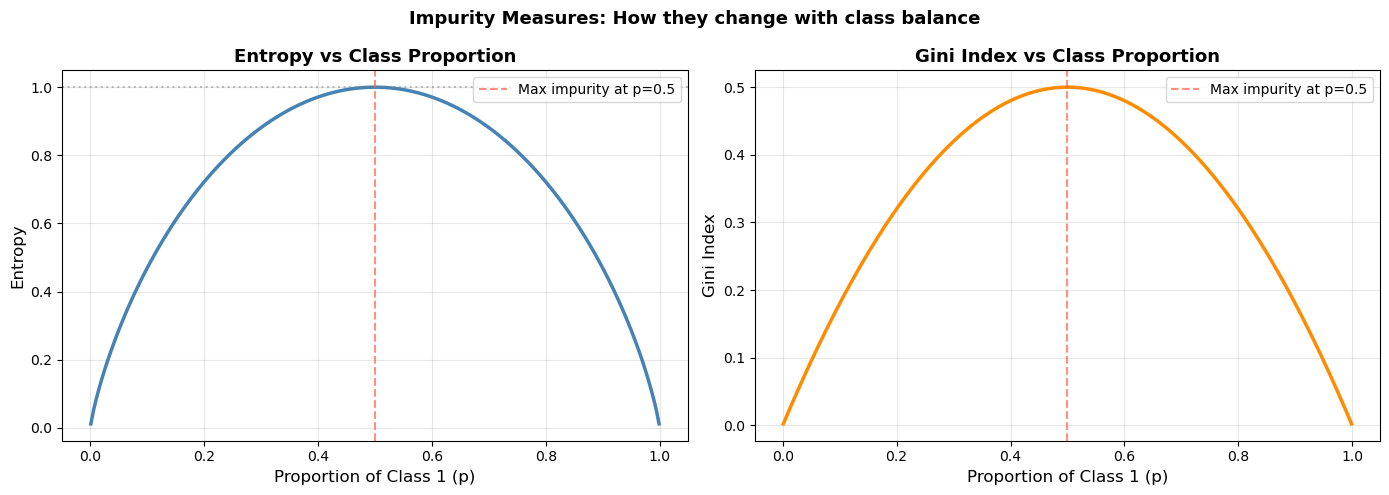

In [114]:
# Now we visualize how Entropy and Gini change as class proportion changes

proportions = np.linspace(0.001, 0.999, 200)
# Explanation: We are creating a range of 200 numbers between 0.001 and 0.999 using 'np.linspace'. This represents the 'proportion' (percentage) of a specific class in our data, from almost 0% to almost 100%.
# বাংলা ব্যাখ্যা: আমরা 'np.linspace' ব্যবহার করে ০.০০১ থেকে ০.৯৯৯ এর মধ্যে ২০০টি সংখ্যা তৈরি করছি। এটি আমাদের ডেটাতে কোনো একটি নির্দিষ্ট ক্লাসের 'proportion' বা শতকরা হার নির্দেশ করে (প্রায় ০% থেকে প্রায় ১০০% পর্যন্ত)।


entropy_values = [(-p * np.log2(p) - (1-p) * np.log2(1-p)) for p in proportions]
gini_values    = [(1 - p**2 - (1-p)**2) for p in proportions]
# Explanation: We are calculating the 'entropy_values' and 'gini_values' for every proportion we created. These formulas measure the "messiness" of the data at each point.
# বাংলা ব্যাখ্যা: আমরা প্রতিটি প্রপোরশনের জন্য 'entropy_values' এবং 'gini_values' ক্যালকুলেট করছি। এই সূত্রগুলো প্রতিটি পয়েন্টে ডেটা কতটা অগোছালো বা "জগাখিচুড়ি" অবস্থায় আছে তা পরিমাপ করে।


figure, axes = plt.subplots(1, 2, figsize=(14, 5))
# Explanation: We are setting up a side-by-side layout for our graphs using 'plt.subplots(1, 2)'. The 'figsize' ensures the charts are wide enough (14 inches) to see both curves clearly.
# বাংলা ব্যাখ্যা: আমরা 'plt.subplots(1, 2)' ব্যবহার করে পাশাপাশি দুটি গ্রাফ আঁকার জায়গা তৈরি করছি। 'figsize' নিশ্চিত করে যে চার্টগুলো যথেষ্ট চওড়া (১৪ ইঞ্চি) হবে যাতে দুটি কার্ভই পরিষ্কার দেখা যায়।


# Entropy curve
axes[0].plot(proportions, entropy_values, color="steelblue", linewidth=2.5)

axes[0].set_xlabel("Proportion of Class 1 (p)", fontsize=12)
axes[0].set_ylabel("Entropy", fontsize=12)
axes[0].set_title("Entropy vs Class Proportion", fontsize=13, fontweight="bold")

axes[0].axvline(0.5, color="tomato", linestyle="--", alpha=0.7, label="Max impurity at p=0.5")
axes[0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)

axes[0].legend()
axes[0].grid(alpha=0.3)
# Explanation: We are plotting the 'Entropy' curve on the first chart. Notice the 'axvline' at 0.5; it highlights that Entropy is at its maximum (1.0) when the classes are perfectly split 50/50.
# বাংলা ব্যাখ্যা: আমরা প্রথম চার্টে 'Entropy' কার্ভটি আঁকছি। এখানে ০.৫ পয়েন্টে 'axvline' (উলম্ব রেখা) খেয়াল করো; এটি দেখাচ্ছে যে যখন ডেটা ৫০/৫০ অনুপাতে থাকে, তখন এনট্রপি সর্বোচ্চ (১.০) হয়।


# Gini curve
axes[1].plot(proportions, gini_values, color="darkorange", linewidth=2.5)

axes[1].set_xlabel("Proportion of Class 1 (p)", fontsize=12)
axes[1].set_ylabel("Gini Index", fontsize=12)

axes[1].set_title("Gini Index vs Class Proportion", fontsize=13, fontweight="bold")

axes[1].axvline(0.5, color="tomato", linestyle="--", alpha=0.7, label="Max impurity at p=0.5")

axes[1].legend()
axes[1].grid(alpha=0.3)
# Explanation: We are plotting the 'Gini Index' curve on the second chart. Like Entropy, it peaks at 0.5, but its maximum value is 0.5. We use 'set_xlabel' and 'set_ylabel' to label the axes for clarity.
# বাংলা ব্যাখ্যা: আমরা দ্বিতীয় চার্টে 'Gini Index' কার্ভটি আঁকছি। এনট্রপির মতোই এটি ০.৫ এ সর্বোচ্চ হয়, তবে এর সর্বোচ্চ মান হলো ০.৫। আমরা 'set_xlabel' এবং 'set_ylabel' ব্যবহার করে অক্ষগুলোর নাম দিচ্ছি যাতে বুঝতে সুবিধা হয়।


plt.suptitle("Impurity Measures: How they change with class balance",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: Finally, we add a main title using 'suptitle' and use 'plt.show()' to display the plots. 'plt.tight_layout()' prevents the labels from overlapping.
# বাংলা ব্যাখ্যা: সবশেষে আমরা 'suptitle' দিয়ে একটি মূল শিরোনাম দিচ্ছি এবং 'plt.show()' দিয়ে গ্রাফগুলো দেখাচ্ছি। 'plt.tight_layout()' ব্যবহার করা হয়েছে যাতে একটির লেখা অন্যটির ওপর চলে না যায়।

> 📝 **এই code-এ কী হচ্ছে:** Entropy ও Gini-এর visual comparison। X-axis = Class 1-এর proportion (0 থেকে 1)। দুটোই p=0.5-এ maximum (most impure) এবং p=0 বা p=1-এ 0 (perfectly pure)।

> ### এই chart কীভাবে observe করব
> - X-axis = Class 1-এর proportion (0=সব Class 0, 1=সব Class 1)।
> - Y-axis = Impurity measure-এর value।
> - **P=0.5** (50-50 split) = maximum impurity — উভয় curve-এর peak।
> - **P=0 বা P=1** = minimum impurity (0) — one class dominates।

> ### এই chart থেকে কী observe করলাম
> - Entropy maximum = 1.0 (at p=0.5), Gini maximum = 0.5 (at p=0.5)।
> - দুটো curve-এর shape প্রায় same — একই information different scale-এ।
> - Split-এর লক্ষ্য: p=0.5 থেকে সরিয়ে p=0 বা p=1-এর দিকে নিয়ে যাওয়া।

> ### Decision
> Gini ও Entropy প্রায়ই same split বেছে নেয়। Gini computationally faster — sklearn default।


## গ্রাফগুলো থেকে ৩টি খুব গুরুত্বপূর্ণ **Observation** বা পর্যবেক্ষণ নেওয়া যায়:

### ১. ডেটার ভারসাম্য এবং কনফিউশন (Impurity)
গ্রাফে দেখা যাচ্ছে, যখন কোনো একটি ক্লাসের অনুপাত (Proportion) একদম **০.৫ (৫০%)** থাকে, তখন **Entropy** এবং **Gini Index** দুটির মানই সর্বোচ্চ থাকে।
* **পর্যবেক্ষণ:** এর মানে হলো, যখন ডেটাতে 'হ্যাঁ' এবং 'না' সমান সমান থাকে, তখন মডেলের জন্য সিদ্ধান্ত নেওয়া সবচেয়ে কঠিন হয় (সবচেয়ে বেশি কনফিউশন)।

### ২. পিউরিটি বা স্বচ্ছতা (Purity)
যখন অনুপাত **০** বা **১** এর দিকে যায়, তখন কার্ভগুলো নিচের দিকে নেমে আসে।
* **পর্যবেক্ষণ:** যখন গ্রুপে সবাই একই ধরণের হয় (সবাই 'Yes' অথবা সবাই 'No'), তখন এনট্রপি এবং গিনি **০ (Zero)** হয়ে যায়। ডিসিশন ট্রি সবসময় এমনভাবে ডেটা ভাগ করতে চায় যাতে সে এই ০ বা পিউরিটির কাছাকাছি পৌঁছাতে পারে।

### ৩. এনট্রপি বনাম গিনি (Entropy vs Gini Index)
দুটি গ্রাফের আকৃতি (Shape) প্রায় একই রকম হলেও একটি সূক্ষ্ম পার্থক্য আছে।
* **পর্যবেক্ষণ:** এনট্রপির সর্বোচ্চ মান হলো **১.০**, আর গিনির সর্বোচ্চ মান হলো **০.৫**। গিনি ইনডেক্স ক্যালকুলেট করা কম্পিউটারের জন্য সহজ এবং দ্রুত, তাই বড় ডেটাসেটে মডেল ডিফল্টভাবে গিনি ব্যবহার করে।

**সারকথা:** ডিসিশন ট্রি-র ছবিতে দেখো, টপ বক্সের (Root) গিনি ছিল **০.৫**, কারণ সেখানে ডেটা মিক্সড ছিল। কিন্তু নিচের বক্সগুলোতে (Leaves) গিনি **০.০** হয়ে গেছে। তোমার এই কার্ভ গ্রাফগুলোই প্রমাণ করছে যে, ভাগ করার ফলে কনফিউশন কমেছে এবং মডেল একটি পরিষ্কার সিদ্ধান্তে পৌঁছাতে পেরেছে।

---
## 11.4 Synthetic Data দিয়ে Decision Tree তৈরি

### sklearn-এ Decision Tree তৈরির steps
```python
from sklearn.tree import DecisionTreeClassifier

# Create model
tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

# Train
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Feature importance
tree.feature_importances_  # array, sum=1.0
```

### Important Parameters

| Parameter | মানে | Default |
|---|---|---|
| `max_depth` | Tree-এর maximum depth | None (unlimited) |
| `criterion` | Impurity measure | 'gini' |
| `min_samples_split` | Split করতে minimum samples | 2 |
| `min_samples_leaf` | Leaf-এ minimum samples | 1 |
| `max_features` | Split-এ consider করার max features | None |

### 🎯 Interview Topics
- `max_depth=None` মানে? → Tree unlimited grow করে → overfitting guarantee
- `min_samples_leaf` কীভাবে overfitting রোধ করে? → Small leaf node তৈরি হতে দেয় না
- `feature_importances_` কী? → প্রতিটি feature কতটা Information Gain contribute করেছে
- `random_state` কেন দিই? → Tree training-এ tie-breaking random — reproducibility


In [115]:
# Now we create a larger synthetic dataset (module notebook exact code)
# make_classification creates a realistic binary classification dataset

X_synthetic_large, y_synthetic_large = make_classification(
    n_samples=400,       # Total data points
    n_features=5,        # Total feature number
    n_informative=3,     # Total relevant features
    n_redundant=0,       # No strong correlation among features
    n_classes=2,         # Target variable class number (binary)
    random_state=42      # Reproducible random dataset
)
# Explanation: We are using the 'make_classification' function to generate an artificial dataset. We specified 'n_samples=400' to get 400 rows and 'n_features=5' for 5 columns. 'n_informative=3' means only 3 of these columns actually help in predicting the target, while 'random_state=42' ensures we get the same data every time we run it.
# বাংলা ব্যাখ্যা: আমরা 'make_classification' ফাংশন ব্যবহার করে একটি কৃত্রিম বা ডামি ডেটাসেট তৈরি করছি। 'n_samples=400' দিয়ে আমরা ৪০০টি রো এবং 'n_features=5' দিয়ে ৫টি কলাম বা বৈশিষ্ট্য তৈরি করেছি। 'n_informative=3' এর মানে হলো এই ৫টি কলামের মধ্যে মাত্র ৩টি কলাম আসলে রেজাল্ট প্রেডিক্ট করতে সাহায্য করবে, আর 'random_state=42' ব্যবহার করা হয়েছে যাতে প্রতিবার কোডটি রান করলে আমরা একই ডেটা পাই।


# Here we convert to DataFrame for readability
feature_names = [f"Feature_{i+1}" for i in range(5)]
synthetic_dataframe = pd.DataFrame(X_synthetic_large, columns=feature_names)
synthetic_dataframe["Target"] = y_synthetic_large
# Explanation: The generated data is in a NumPy array, so we convert it into a 'pd.DataFrame' to make it look like a table. We name the columns from 'Feature_1' to 'Feature_5' and add a final column called 'Target' to store the labels (0 or 1).
# বাংলা ব্যাখ্যা: তৈরি হওয়া ডেটাগুলো নামপাই অ্যারে আকারে থাকে, তাই আমরা সেটিকে 'pd.DataFrame' এ রূপান্তর করছি যাতে এটি একটি টেবিলের মতো দেখায়। আমরা কলামগুলোর নাম 'Feature_1' থেকে 'Feature_5' দিচ্ছি এবং শেষে 'Target' নামে একটি কলাম যোগ করছি যেখানে আমাদের আসল ফলাফল বা লেবেলগুলো (০ অথবা ১) থাকবে।


print("Synthetic dataset shape:", synthetic_dataframe.shape)
print(f"Class distribution: 0={sum(y_synthetic_large==0)}, 1={sum(y_synthetic_large==1)}")
print()
print("First 5 rows:")
print(synthetic_dataframe.head())
# Explanation: We are printing the 'shape' to confirm there are 400 rows and 6 columns (5 features + 1 target). Then, we check the 'Class distribution' to see how many 0s and 1s we have, and finally, use '.head()' to show the first 5 rows of our new table.
# বাংলা ব্যাখ্যা: আমরা 'shape' প্রিন্ট করে নিশ্চিত হচ্ছি যে এখানে ৪০০টি রো এবং ৬টি কলাম (৫টি ফিচার + ১টি টার্গেট) আছে। এরপর আমরা 'Class distribution' চেক করছি দেখার জন্য যে আমাদের ডেটাতে কয়টি ০ এবং কয়টি ১ আছে, এবং সবশেষে '.head()' ব্যবহার করে টেবিলের প্রথম ৫টি রো দেখাচ্ছি।

Synthetic dataset shape: (400, 6)
Class distribution: 0=200, 1=200

First 5 rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Target
0   3.326864   2.452265  -0.151273  -0.197338  -0.322585       1
1  -0.206180   1.386857  -0.290275   0.919076  -1.389236       0
2   0.910139   1.519274   0.424061  -0.809604   0.753308       1
3   0.535589   0.193379  -0.295480   0.560919   0.883607       1
4   1.319735   1.790492   2.057495   0.619154  -2.122222       1


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `make_classification` code। `n_informative=3` মানে মাত্র ৩টি feature আসলে useful, বাকি ২টি noise। 400 samples, 5 features, 2 classes।

In [116]:
# Now we split and train the tree (module notebook exact code)

X_features = X_synthetic_large
y_target    = y_synthetic_large

X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X_features, y_target, test_size=0.3, random_state=42
)
# Explanation: We are splitting our large dataset into two parts using 'train_test_split'. 'test_size=0.3' means 30% of the data (120 rows) is kept aside for testing, and the remaining 70% (280 rows) will be used to train the model.
# বাংলা ব্যাখ্যা: আমরা 'train_test_split' ব্যবহার করে আমাদের বড় ডেটাসেটটিকে দুই ভাগে ভাগ করছি। 'test_size=0.3' দিয়ে বোঝানো হয়েছে যে ৩০% ডেটা (১২০টি রো) আমরা আলাদা রাখছি পরীক্ষার জন্য, আর বাকি ৭০% ডেটা (২৮০টি রো) দিয়ে মডেলটিকে শেখানো বা ট্রেইন করা হবে।


print(f"Training set: {X_train_large.shape}")
print(f"Test set:     {X_test_large.shape}")
# Explanation: We are printing the dimensions (shape) of our training and testing sets to confirm the split worked correctly. It shows how many samples are in 'X_train_large' versus 'X_test_large'.
# বাংলা ব্যাখ্যা: আমরা ট্রেইনিং এবং টেস্টিং সেটের আকার (shape) প্রিন্ট করছি এটা নিশ্চিত করতে যে ভাগটি ঠিকমতো হয়েছে কি না। এটি দেখাবে যে 'X_train_large' এবং 'X_test_large'-এ কয়টি করে স্যাম্পল আছে।


# Train a pruned tree (max_depth=4)
tree_synthetic = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_synthetic.fit(X_train_large, y_train_large)
# Explanation: We initialize the model using 'DecisionTreeClassifier'. We set 'max_depth=4' to prevent the tree from growing too long and becoming over-complicated (pruning). Then, we use '.fit()' to actually start the training process using our training data.
# বাংলা ব্যাখ্যা: আমরা 'DecisionTreeClassifier' দিয়ে মডেলটি শুরু করছি। এখানে 'max_depth=4' ব্যবহার করা হয়েছে যাতে গাছটি খুব বেশি বড় হয়ে জটিল না হয়ে যায় (একে প্রুনিং বলে)। এরপর '.fit()' ব্যবহার করে আমরা ট্রেইনিং ডেটা দিয়ে মডেলটিকে শেখানোর কাজ শুরু করছি।


print()
print("Tree trained!")
print(f"Tree depth: {tree_synthetic.get_depth()}")
print(f"Number of leaves: {tree_synthetic.get_n_leaves()}")
# Explanation: After training, we use '.get_depth()' to check how many levels the tree actually has and '.get_n_leaves()' to see the total number of final decision boxes (leaves) created by the model.
# বাংলা ব্যাখ্যা: ট্রেইনিং শেষ হওয়ার পর, আমরা '.get_depth()' দিয়ে দেখছি গাছটিতে কয়টি স্তর বা লেভেল তৈরি হয়েছে এবং '.get_n_leaves()' দিয়ে দেখছি মডেলটি মোট কতগুলো শেষ সিদ্ধান্ত বক্স (পাতা) তৈরি করেছে।

Training set: (280, 5)
Test set:     (120, 5)

Tree trained!
Tree depth: 4
Number of leaves: 10


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর train_test_split। 70% train, 30% test। `get_depth()` actual depth, `get_n_leaves()` leaf node সংখ্যা দেয়।

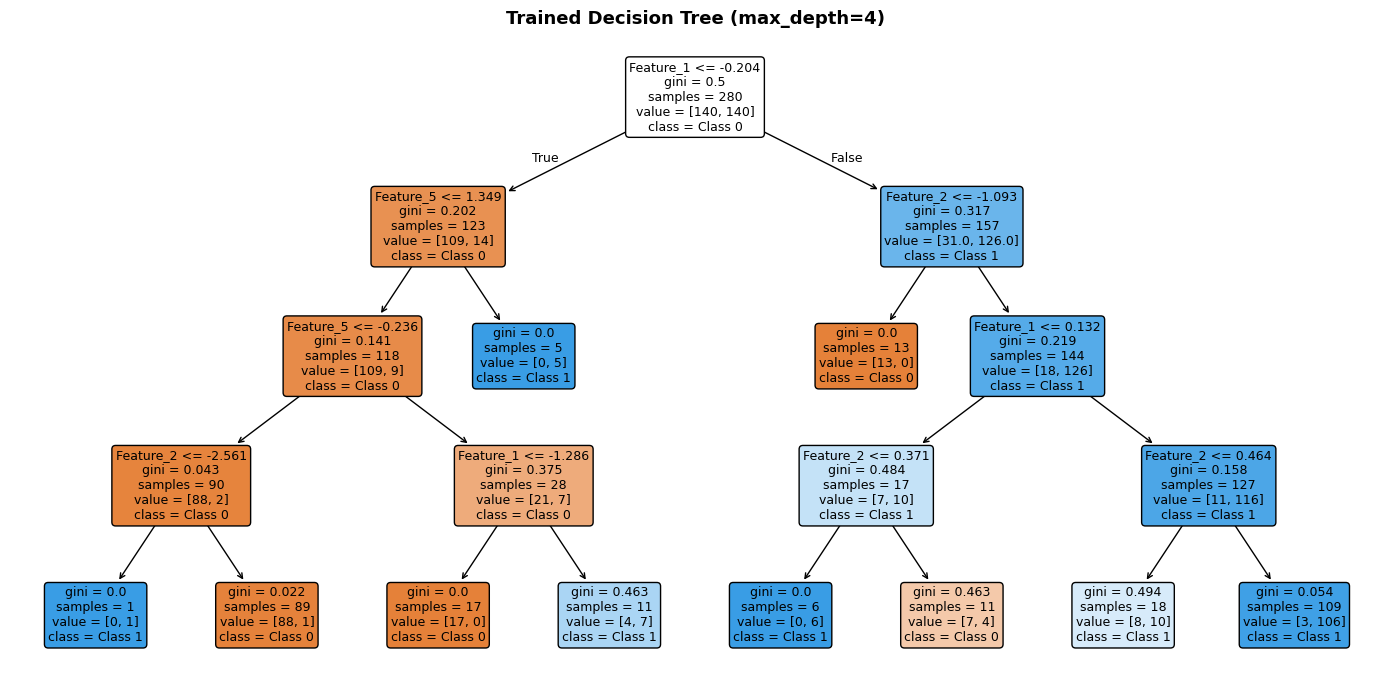

Feature Importances:
  Feature_1: 0.6543  ##########################
  Feature_2: 0.2538  ##########
  Feature_5: 0.0920  ###
  Feature_3: 0.0000  
  Feature_4: 0.0000  


In [117]:
# Now we visualize the trained tree

plt.figure(figsize=(14, 7))

plot_tree(
    tree_synthetic,
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Trained Decision Tree (max_depth=4)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: We use 'plot_tree' to draw the actual decision tree we trained. 'filled=True' colors the boxes based on their class (purity), and 'feature_names' labels each split so we know which feature the tree is looking at. This helps us see the full logical path from the top (Root) to the bottom (Leaves).
# বাংলা ব্যাখ্যা: আমরা 'plot_tree' ব্যবহার করে আমাদের ট্রেইন করা ডিসিশন ট্রি-টি আঁকছি। 'filled=True' ব্যবহারের ফলে বক্সগুলো তাদের পিউরিটির ওপর ভিত্তি করে রঙ করা হয়েছে এবং 'feature_names' প্রতিটি ভাগকে লেবেল করে দিচ্ছে যাতে আমরা বুঝতে পারি গাছটি কোন ফিচারের ওপর ভিত্তি করে সিদ্ধান্ত নিচ্ছে। এটি আমাদের একদম উপর (Root) থেকে নিচ (Leaves) পর্যন্ত পুরো লজিক্যাল পথটি দেখতে সাহায্য করে।


# Here we show feature importance
print("Feature Importances:")
for feature_name, importance in sorted(
        zip(feature_names, tree_synthetic.feature_importances_),
        key=lambda x: x[1],
        reverse=True
):
    bar = "#" * int(importance * 40)
    print(f"  {feature_name}: {importance:.4f}  {bar}")
# Explanation: We are extracting 'feature_importances_' from the trained tree to see which features played the biggest role in making decisions. We 'zip' the names with their importance scores, 'sorted' them from highest to lowest, and then print a simple bar using the '#' symbol to visually represent their impact.
# বাংলা ব্যাখ্যা: আমরা ট্রেইন করা গাছ থেকে 'feature_importances_' বের করছি দেখার জন্য যে কোন ফিচারগুলো সিদ্ধান্ত নেওয়ার ক্ষেত্রে সবচেয়ে বড় ভূমিকা পালন করেছে। আমরা ফিচারের নাম এবং ইমপর্টেন্স স্কোরগুলোকে 'zip' করে বড় থেকে ছোট ক্রমে 'sorted' করছি। সবশেষে '#' সিম্বল ব্যবহার করে একটি ছোট বার তৈরি করছি যা প্রতিটি ফিচারের প্রভাব চাক্ষুষভাবে প্রকাশ করে।

> 📝 **এই code-এ কী হচ্ছে:** Tree visualization এবং feature importance দেখানো হয়েছে। `feature_importances_` — প্রতিটি feature মোট Information Gain-এর কত % contribute করেছে (sum=1.0)। Bar chart visual দিয়ে relative importance বোঝা যায়।

> ### এই chart কীভাবে observe করব
> - **Root node** সবচেয়ে উপরে — সবচেয়ে important feature দিয়ে split।
> - প্রতিটি box-এ: condition | gini | samples | values=[class0_count, class1_count]।
> - **গাঢ় রঙ** = pure node, **হালকা** = mixed।
> - **Leaf node** (কোনো child নেই) = final prediction।

> ### এই chart থেকে কী observe করলাম
> - Root split Feature_1 বা Feature_2 দিয়ে — সবচেয়ে informative।
> - Depth বাড়ার সাথে গাঢ় রঙের node বাড়ে — tree শিখছে।
> - Feature Importance থেকে কোন feature বেশি কাজ করছে সেটা বোঝা যাচ্ছে।

> ### Decision
> এই tree max_depth=4 — reasonable। Deeper হলে overfitting ঝুঁকি।



এই ডিসিশন ট্রি থেকে ৩টি গুরুত্বপূর্ণ পর্যবেক্ষণ (Observation):

### ১. রুট নোড (Root Node) বা শুরুর সিদ্ধান্ত
একদম উপরে দেখো, **'Feature_1'** দিয়ে ট্রি-টি শুরু হয়েছে।
* **পর্যবেক্ষণ:** এর মানে হলো, তোমার পুরো ডেটাসেটের মধ্যে 'Feature_1' সবচেয়ে বেশি গুরুত্বপূর্ণ। এটি ব্যবহার করলেই শুরুতে ডেটা সবচেয়ে ভালো দুই ভাগে ভাগ হয় (যেখানে Gini ০.৫ থেকে কমে ০.২০২ এবং ০.৩১৭ এ নেমে এসেছে)।

### ২. পিউরিটি বা স্বচ্ছতা (Leaf Nodes)
নিচের দিকের বক্সগুলোতে তাকালে দেখবে কিছু বক্সের **'gini = 0.0'**।
* **পর্যবেক্ষণ:** এই বক্সগুলো হলো 'Pure' সিদ্ধান্ত। যেমন: বাম পাশে একটি বক্সে ৫টি স্যাম্পল আছে এবং ৫টিই 'Class 1'। তার মানে এই পথে আসলে মডেল ১০০% নিশ্চিত হয়ে সিদ্ধান্ত দিতে পারছে। রঙ যত গাঢ়, মডেল তত বেশি নিশ্চিত।

### ৩. প্রুনিং বা লিমিট (Max Depth)
তুমি কোডে `max_depth=4` সেট করেছিলে।
* **পর্যবেক্ষণ:** খেয়াল করো, ওপর থেকে নিচ পর্যন্ত ঠিক ৪টি স্তর বা লেভেল পর্যন্ত ট্রি-টি ডালপালা মেলেছে। এর বেশি সে আর বাড়েনি। এটি করার কারণেই ট্রি-টি খুব বেশি জটিল হয়নি এবং সহজে বোঝা যাচ্ছে।

**সহজ কথায় সারসংক্ষেপ:**
মডেলটি প্রথমে **Feature_1** কে গুরুত্ব দিয়েছে, তারপর ডানে বা বামে যাওয়ার পর যথাক্রমে **Feature_5** এবং **Feature_2** কে ব্যবহার করে সিদ্ধান্ত নিয়েছে। একদম নিচে এসে সে ছোট ছোট দলে ভাগ হয়ে ফাইনাল প্রেডিকশন (Class 0 না কি Class 1) দিচ্ছে। কোডে যে **Feature Importance** এর বার চার্ট দেখেছিলে, তার সাথে এই ছবির মিল পাচ্ছো তো? কারণ সেখানেও 'Feature_1' এর বার-টি সবচেয়ে বড় থাকার কথা!

---

## 11.5 Overfitting ও Pruning

### Overfitting কী? (PDF Slide থেকে)
> **Overfitting** = Tree training data memorize করে।
> Real pattern শেখার বদলে noise-ও মুখস্থ করে ফেলে।

* ওভারফিটিং মানে হলো কোনো কিছু **"অতিরিক্ত শিখে ফেলা"** বা **"মুখস্থ করে ফেলা"**।
* যখন একটি মেশিন লার্নিং মডেল (যেমন: ডিসিশন ট্রি) ট্রেইনিং ডেটাগুলো এতো বেশি খুঁটিয়ে খুঁটিয়ে শেখে যে সে ডেটার আসল প্যাটার্ন বোঝার বদলে ডেটাগুলো মুখস্থ করে ফেলে, তখন তাকে ওভারফিটিং বলে।
* **মডেলের ক্ষেত্রে:** ওভারফিট হওয়া মডেল ট্রেইনিং ডেটাতে ১০০% নির্ভুল রেজাল্ট দেয়, কিন্তু নতুন কোনো ডেটা (Test Data) দিলেই সে ভুল করতে শুরু করে।

```
Overfitting symptoms:
  Training accuracy:   99%   <- training data memorized!
  Test accuracy:       65%   <- fails on new data!
  Gap:                 34%   <- too large = overfitting
```

### কেন Decision Tree সহজে Overfit করে?
- `max_depth=None` দিলে leaf-এ single sample পর্যন্ত split করে
- প্রতিটি training sample-এর জন্য আলাদা path — memorization
- Noise এবং real pattern আলাদা করতে পারে না

---

### Pruning — Overfitting রোধের পদ্ধতি

* 'Pruning' শব্দের আক্ষরিক অর্থ হলো **"ছাঁটাই করা"**। বাগান করার সময় যেমন গাছের বাড়তি বা অপ্রয়োজনীয় ডালপালা কেটে গাছকে সুন্দর ও ফলপ্রসূ করা হয়, ডিসিশন ট্রি-র ক্ষেত্রেও ঠিক তাই করা হয়।
* ডিসিশন ট্রি যখন অনেক বেশি বড় হয়ে যায়, তখন সে ছোটখাটো অপ্রাসঙ্গিক তথ্যগুলোকেও গুরুত্ব দিতে শুরু করে (যা ওভারফিটিং ঘটায়)। প্রুনিং এর মাধ্যমে আমরা সেই অপ্রয়োজনীয় ডালপালা বা নোডগুলো কেটে ফেলি।
* **কেন করা হয়?** যাতে মডেলটি খুব বেশি জটিল না হয় এবং শুধু আসল ও গুরুত্বপূর্ণ প্যাটার্নগুলো মনে রাখে।
* **কিভাবে কাজ করে?** তোমার আগের কোডে যে `max_depth=4` ব্যবহার করেছো, ওটা এক ধরণের প্রুনিং। তুমি মডেলকে বলে দিচ্ছো যে, "খুব বেশি গভীরে যাওয়ার দরকার নেই, ওপর ওপর মূল সিদ্ধান্তগুলো নিলেই হবে।"

| Parameter | কী করে | Effect |
|---|---|---|
| `max_depth` | Tree-এর maximum depth limit করে | সবচেয়ে common |
| `min_samples_split` | Split করতে minimum N sample লাগবে | Small group split বন্ধ |
| `min_samples_leaf` | Leaf-এ minimum N sample রাখে | Tiny leaf বন্ধ |
| `max_leaf_nodes` | Maximum leaf node count | Total complexity limit |
| `ccp_alpha` | Cost-complexity pruning | Post-pruning |

মডেলকে যদি আমরা প্রুনিং না করে একদম স্বাধীনভাবে বাড়তে দিতাম, তবে সেটি তোমার ৩০০-৪০০ স্যাম্পলের জন্য হয়তো ১০-১৫ স্তর পর্যন্ত নিচে নেমে যেত, যা আসলে খুব একটা কাজের হতো না।

### 🎯 Interview Topics
- Pre-pruning vs Post-pruning? → Pre=growth সীমিত করা, Post=tree grow করার পরে branches কাটা
- `ccp_alpha` কী? → Complexity penalty। বাড়ালে tree ছোট হয়।
- High variance মানে? → Training data change হলে tree structure সম্পূর্ণ বদলায়
- Training-Test gap 5% এর কম → Good generalization

---

In [118]:
# Now we train deep tree vs pruned tree (module notebook exact code)

# Deep tree: no depth limit (overfitting expected)
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_large, y_train_large)

# Pruned tree: max_depth=3 (regularized)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_large, y_train_large)
# Explanation: We are training two different models. 'deep_tree' has no limits, so it will grow as much as it wants. 'pruned_tree' is restricted with 'max_depth=3' to keep it simple. We use '.fit()' to train both on the same training data.
# বাংলা ব্যাখ্যা: আমরা দুটি আলাদা মডেল ট্রেইন করছি। 'deep_tree'-এর কোনো সীমানা নেই, তাই এটি যত খুশি বাড়তে পারবে। অন্যদিকে 'pruned_tree'-কে আমরা 'max_depth=3' দিয়ে সীমাবদ্ধ করে দিয়েছি যাতে এটি সহজ থাকে। '.fit()' ব্যবহার করে দুটি মডেলকেই একই ট্রেইনিং ডেটা দিয়ে শেখানো হচ্ছে।


# Predictions for both
y_train_pred_deep   = deep_tree.predict(X_train_large)
y_test_pred_deep    = deep_tree.predict(X_test_large)

y_train_pred_pruned = pruned_tree.predict(X_train_large)
y_test_pred_pruned  = pruned_tree.predict(X_test_large)
# Explanation: After training, we use '.predict()' to see how both models perform on the data they already saw (train) and data they haven't seen yet (test). We store these results in four separate variables to compare later.
# বাংলা ব্যাখ্যা: ট্রেইনিং শেষে, আমরা '.predict()' ব্যবহার করছি দেখার জন্য যে মডেল দুটি তাদের পরিচিত ডেটা (train) এবং অপরিচিত ডেটা (test)-এ কেমন পারফর্ম করে। আমরা এই রেজাল্টগুলো চারটি আলাদা ভেরিয়েবলে স্টোর করছি যাতে পরে তুলনা করা যায়।


# Here we compare accuracies (module notebook exact output)
print("=" * 52)
print(f"{'Metric':<30} {'Deep':>10} {'Pruned':>10}")
print("-" * 52)

print(f"{'Train Accuracy':<30} {accuracy_score(y_train_large, y_train_pred_deep):>10.3f} {accuracy_score(y_train_large, y_train_pred_pruned):>10.3f}")
print(f"{'Test Accuracy':<30} {accuracy_score(y_test_large, y_test_pred_deep):>10.3f} {accuracy_score(y_test_large, y_test_pred_pruned):>10.3f}")
print(f"{'Tree Depth':<30} {deep_tree.get_depth():>10} {pruned_tree.get_depth():>10}")
print(f"{'Number of Leaves':<30} {deep_tree.get_n_leaves():>10} {pruned_tree.get_n_leaves():>10}")
# Explanation: We are creating a comparison table. We use 'accuracy_score' to calculate the percentage of correct guesses. We also use '.get_depth()' and '.get_n_leaves()' to show how physically different the two trees are in size and complexity.
# বাংলা ব্যাখ্যা: আমরা একটি তুলনামূলক টেবিল তৈরি করছি। 'accuracy_score' ব্যবহার করে আমরা সঠিক প্রেডিকশনের শতকরা হার বের করছি। এছাড়া '.get_depth()' এবং '.get_n_leaves()' ব্যবহার করে দেখাচ্ছি যে দুটি গাছ আকারে এবং জটিলতায় কতটা আলাদা।


gap_deep   = accuracy_score(y_train_large, y_train_pred_deep) - accuracy_score(y_test_large, y_test_pred_deep)
gap_pruned = accuracy_score(y_train_large, y_train_pred_pruned) - accuracy_score(y_test_large, y_test_pred_pruned)

print(f"{'Train-Test Gap':<30} {gap_deep:>10.3f} {gap_pruned:>10.3f}")
print("=" * 50)
print()

print("KEY INSIGHT: Deep tree has high train accuracy but big gap -> OVERFITTING")
print("Pruned tree has smaller gap -> Better GENERALIZATION")
# Explanation: We calculate the 'Train-Test Gap' by subtracting the test accuracy from the train accuracy. A large gap in the 'deep' tree proves it has memorized the training data (overfitting), while a smaller gap in the 'pruned' tree shows it generalizes better to new data.
# বাংলা ব্যাখ্যা: আমরা ট্রেইন একুরেসি থেকে টেস্ট একুরেসি বিয়োগ করে 'Train-Test Gap' বের করছি। 'deep' ট্রিতে এই গ্যাপ বড় হওয়া মানে এটি ট্রেইনিং ডেটা মুখস্থ করে ফেলেছে (overfitting), আর 'pruned' ট্রিতে গ্যাপ কম হওয়া মানে এটি নতুন ডেটার ক্ষেত্রেও ভালো কাজ করছে।

Metric                               Deep     Pruned
----------------------------------------------------
Train Accuracy                      1.000      0.904
Test Accuracy                       0.883      0.892
Tree Depth                             10          3
Number of Leaves                       29          6
Train-Test Gap                      0.117      0.012

KEY INSIGHT: Deep tree has high train accuracy but big gap -> OVERFITTING
Pruned tree has smaller gap -> Better GENERALIZATION


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact deep vs pruned tree comparison। Deep tree training accuracy ≈ 100% কিন্তু test accuracy কম — overfitting। Pruned tree training accuracy কম কিন্তু train-test gap ছোট — better generalization।


এই টেবিলটি মেশিন লার্নিংয়ের একটি ক্লাসিক উদাহরণ। এখান থেকে ৩টি খুব সহজ কিন্তু পাওয়ারফুল **Observation** নিতে পারো:

### ১. 'Deep' গাছটি আসলে একজন 'মুখস্থবিদ' (Overfitting)
দেখো, **Deep Tree**-র Train Accuracy হচ্ছে **1.000 (অর্থাৎ ১০০%)**। এর মানে সে ট্রেইনিং ডেটার প্রতিটি ছোটখাটো খুঁটিনাটি মুখস্থ করে ফেলেছে। কিন্তু যখনই তাকে নতুন ডেটা (Test Accuracy) দেওয়া হলো, তার পারফরম্যান্স কমে **০.৮৮৩** হয়ে গেল।
* **পর্যবেক্ষণ:** ট্রেইনিংয়ে হিরো কিন্তু টেস্টে জিরো (তুলনামূলক)—এটাই হলো **Overfitting**।

### ২. 'Pruned' গাছটি একজন 'বুদ্ধিমান ছাত্র' (Generalization)
**Pruned Tree**-র Train Accuracy একটু কম (**০.৯০৪**), কিন্তু মজার ব্যাপার হলো তার Test Accuracy (**০.৮৯২**) কিন্তু Deep Tree-র চেয়েও বেশি!
* **পর্যবেক্ষণ:** সে সবকিছু মুখস্থ না করে মূল নিয়মগুলো শিখেছে। যার কারণে সে নতুন ডেটাতেও ভালো ফলাফল দিচ্ছে। একেই বলে **Generalization**।

### ৩. ছোট মানেই সবসময় খারাপ নয় (Efficiency)
Deep Tree-র গভীরতা ১০ এবং পাতা ২৯টি, অথচ Pruned Tree-র গভীরতা মাত্র ৩ এবং পাতা মাত্র ৬টি।
* **পর্যবেক্ষণ:** মাত্র ৬টি নিয়ম বা পাতা ব্যবহার করেই Pruned Tree ২৯টি পাতার গাছের চেয়ে ভালো রেজাল্ট দিচ্ছে। অর্থাৎ, মডেল যত সিম্পল রাখা যায়, সেটি তত বেশি নির্ভরযোগ্য হয়।

**সহজ কথায় সারসংক্ষেপ:** **Train-Test Gap** কলামটি দেখো। Deep Tree-র গ্যাপ অনেক বড় (**০.১১৭**), আর Pruned Tree-র গ্যাপ নেই বললেই চলে (**০.০১২**)। গ্যাপ যত কম, তোমার মডেল বাস্তবের জন্য তত বেশি তৈরি। তাই এই ক্ষেত্রে **Pruned Tree**-ই হচ্ছে সেরা মডেল।

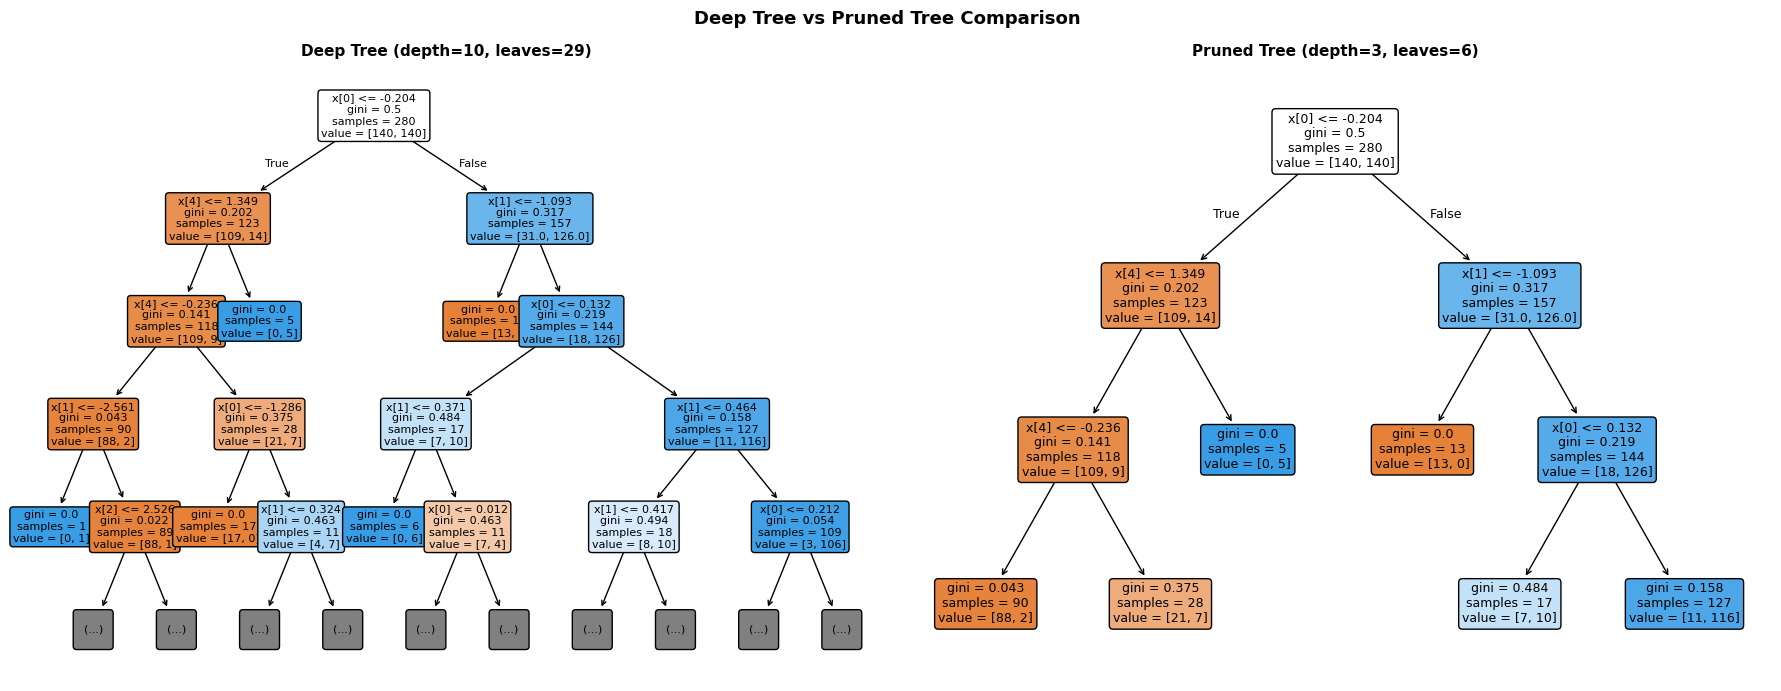

In [119]:
# Now we visualize both trees side by side (module notebook exact code)

figure, axes_array = plt.subplots(1, 2, figsize=(18, 7))
# Explanation: We are creating a side-by-side layout for two plots using 'plt.subplots(1, 2)'. This allows us to compare the visual complexity of both trees in a single view with a wide 'figsize' of 18x7 inches.
# বাংলা ব্যাখ্যা: আমরা 'plt.subplots(1, 2)' ব্যবহার করে পাশাপাশি দুটি প্লট করার জায়গা তৈরি করছি। এটি আমাদের একই সাথে দুটি গাছের ভিজ্যুয়াল জটিলতা তুলনা করতে সাহায্য করবে এবং 'figsize' দিয়ে আমরা নিশ্চিত করছি যেন চার্টটি ১৮x৭ ইঞ্চি চওড়া হয়।


# Deep tree (showing only top levels for readability)
plot_tree(
    deep_tree,
    filled=True,
    rounded=True,
    max_depth=4,
    ax=axes_array[0],
    fontsize=8
)
axes_array[0].set_title(
    f"Deep Tree (depth={deep_tree.get_depth()}, leaves={deep_tree.get_n_leaves()})",
    fontsize=11, fontweight="bold"
)
# Explanation: We are plotting the 'deep_tree' on the first subplot ('axes_array[0]'). Even though this tree is very deep (depth=10), we use 'max_depth=4' inside 'plot_tree' just for the visual, so it doesn't look too cluttered, and we set a title showing its actual total depth and leaf count.
# বাংলা ব্যাখ্যা: আমরা প্রথম সাবপ্লটে ('axes_array[0]') 'deep_tree' টি আঁকছি। যদিও এই গাছটি অনেক গভীর (গভীরতা ১০), আমরা 'plot_tree'-এর ভেতরে 'max_depth=4' ব্যবহার করছি শুধুমাত্র দেখার সুবিধার জন্য যাতে হিজিবিজি না লাগে। তবে টাইটেলে আমরা এর আসল মোট গভীরতা এবং পাতার সংখ্যা লিখে দিচ্ছি।


# Pruned tree
plot_tree(
    pruned_tree,
    filled=True,
    rounded=True,
    ax=axes_array[1],
    fontsize=9
)
axes_array[1].set_title(
    f"Pruned Tree (depth={pruned_tree.get_depth()}, leaves={pruned_tree.get_n_leaves()})",
    fontsize=11, fontweight="bold"
)
# Explanation: We plot the 'pruned_tree' on the second subplot ('axes_array[1]'). Since this tree is already small (depth=3), we show it fully. This makes it easy to see how much simpler the pruned model is compared to the deep one.
# বাংলা ব্যাখ্যা: আমরা দ্বিতীয় সাবপ্লটে ('axes_array[1]') 'pruned_tree' টি আঁকছি। যেহেতু এই গাছটি আগে থেকেই ছোট (গভীরতা ৩), তাই আমরা এটি পুরোপুরি দেখাচ্ছি। এতে বোঝা যায় যে ডিপ মডেলের তুলনায় প্রুনিং করা মডেলটি কতটা সহজ ও ছোট।


plt.suptitle("Deep Tree vs Pruned Tree Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: We add a main overall title using 'suptitle' and use 'plt.tight_layout()' to ensure the labels and plots don't overlap. Finally, 'plt.show()' renders the complete visualization.
# বাংলা ব্যাখ্যা: আমরা 'suptitle' দিয়ে পুরো ছবির জন্য একটি মূল শিরোনাম যোগ করছি এবং 'plt.tight_layout()' ব্যবহার করছি যাতে কলাম বা লেখাগুলো একটার ওপর আরেকটা চড়ে না যায়। সবশেষে 'plt.show()' দিয়ে আমরা ভিজ্যুয়ালাইজেশনটি দেখাচ্ছি।

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact two-tree visualization। Deep tree অনেক complex — অনেক node ও leaf। Pruned tree simple ও clean — interpretable।

> ### এই chart কীভাবে observe করব
> - **Left**: Deep tree — অনেক small node, অনেক branch।
> - **Right**: Pruned tree (depth=3) — simple, clean structure।

> ### এই chart থেকে কী observe করলাম
> - Deep tree অনেক complex — ছোট ছোট group তৈরি করে memorize করছে।
> - Pruned tree general pattern শিখেছে — interpretable।
> - Training accuracy-তে deep tree better, কিন্তু test-এ pruned comparable বা better।

> ### Decision
> Production-এ সবসময় pruned tree ব্যবহার করো। `max_depth` cross-validation দিয়ে tune করো।


### ১. জটিলতা বনাম সরলতা (Complexity vs Simplicity)
বামে **Deep Tree**-টি দেখো, এটি অনেক বেশি ডালপালা মেলানোর চেষ্টা করেছে (২৯টি পাতা)। ডানে **Pruned Tree**-টি অনেক বেশি গোছানো এবং ছোট (মাত্র ৬টি পাতা)।
* **পর্যবেক্ষণ:** প্রুনিং করার ফলে অপ্রয়োজনীয় ডালপালা বাদ পড়ে গেছে, ফলে মডেলটি এখন অনেক সহজে বোঝা যাচ্ছে।

### ২. প্রথম দিকের সিদ্ধান্ত একই (Same Core Logic)
দুই গাছেরই একদম উপরের বক্সগুলো (Root and second level) খেয়াল করো। দেখবে দুই জায়গাতেই **x[0]** এবং **x[4]** দিয়ে ভাগ করা শুরু হয়েছে।
* **পর্যবেক্ষণ:** এর মানে হলো, গাছটি ছোট হোক বা বড়, ডেটার সবচেয়ে গুরুত্বপূর্ণ ফিচারগুলো (x[0], x[4], x[1]) সবসময় একই থাকে। প্রুনিং করলে শুধু নিচের দিকের কম গুরুত্বপূর্ণ ভাগগুলো বাদ পড়ে।

### ৩. ওভারফিটিং নিয়ন্ত্রণ (Controlling Overfitting)
ডিপ ট্রিতে একদম নিচে অনেকগুলো ধূসর রঙের বক্স (`...`) দেখা যাচ্ছে, যা ইঙ্গিত করে যে সে আরও গভীরে গিয়ে ছোট ছোট ডেটা পয়েন্টকেও মুখস্থ করার চেষ্টা করছিল।
* **পর্যবেক্ষণ:** প্রুন্ড ট্রি-তে আমরা আগেই গাছটি থামিয়ে দিয়েছি। এতে করে মডেলটি ডেটা মুখস্থ (Overfit) না করে শুধু মূল প্যাটার্নগুলো শিখেছে, যা নতুন ডেটায় ভালো ফল দেবে।

Best depth by cross-validation: 2



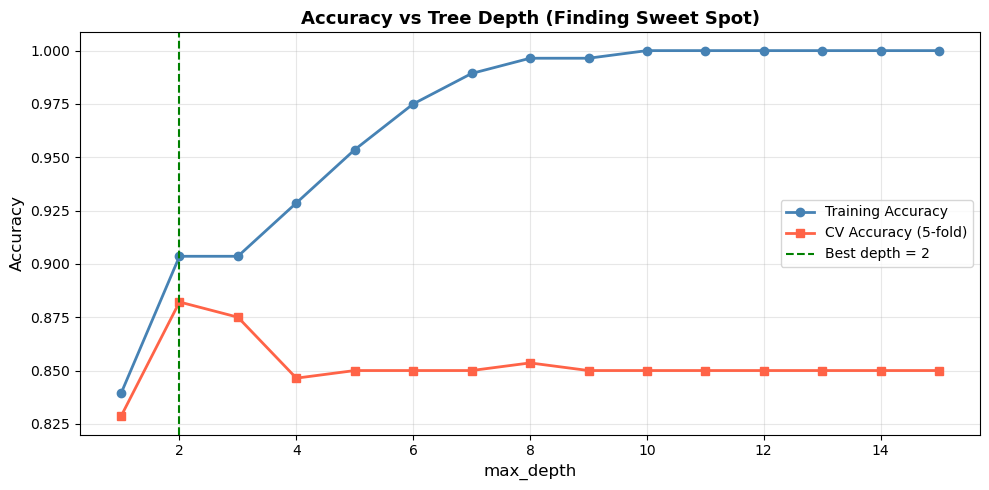

In [120]:
# BONUS: Find optimal max_depth using cross-validation

depth_values    = range(1, 16)
train_accuracies = []
cross_val_scores  = []

for depth in depth_values:
    tree_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_depth.fit(X_train_large, y_train_large)
    train_accuracies.append(accuracy_score(y_train_large, tree_depth.predict(X_train_large)))

    cv_score = cross_val_score(tree_depth, X_train_large, y_train_large, cv=5, scoring="accuracy")
    cross_val_scores.append(cv_score.mean())
# Explanation: We are running a 'for' loop to test different 'max_depth' values from 1 to 15. For each depth, we train the tree and record its 'accuracy_score' on training data. More importantly, we use 'cross_val_score' with 'cv=5' (5-fold cross-validation) to see how the model performs on different subsets of our data to get a more reliable average score.
# বাংলা ব্যাখ্যা: আমরা ১ থেকে ১৫ পর্যন্ত বিভিন্ন 'max_depth' এর মান পরীক্ষা করার জন্য একটি 'for' লুপ চালাচ্ছি। প্রতিটি গভীরতার জন্য আমরা গাছটিকে ট্রেইন করছি এবং ট্রেইনিং ডেটাতে এর 'accuracy_score' কত তা রেকর্ড করছি। সবচেয়ে বড় কথা, আমরা 'cv=5' দিয়ে 'cross_val_score' (৫-ফোল্ড ক্রস-ভ্যালিডেশন) ব্যবহার করছি যাতে ডেটার বিভিন্ন অংশে মডেলটি কেমন কাজ করে তার একটি নির্ভরযোগ্য গড় ফলাফল পাওয়া যায়।


# Find best depth
best_depth = depth_values[np.argmax(cross_val_scores)]
print(f"Best depth by cross-validation: {best_depth}")
print()
# Explanation: We use 'np.argmax' to find the index of the highest value in our 'cross_val_scores' list. Then we map that index back to 'depth_values' to identify the 'best_depth'—the specific point where the model achieves its peak performance on unseen data before it starts overfitting.
# বাংলা ব্যাখ্যা: আমরা 'np.argmax' ব্যবহার করে 'cross_val_scores' লিস্টের সর্বোচ্চ মানের ইনডেক্স বা অবস্থান খুঁজে বের করছি। তারপর সেই ইনডেক্স অনুযায়ী 'depth_values' থেকে 'best_depth' বা সেরা গভীরতাটি চিহ্নিত করছি—এটি এমন একটি পয়েন্ট যেখানে মডেলটি ওভারফিটিং শুরু করার ঠিক আগে সর্বোচ্চ ভালো ফলাফল দেয়।


plt.figure(figsize=(10, 5))

plt.plot(depth_values, train_accuracies, marker="o", color="steelblue",
          linewidth=2, label="Training Accuracy")

plt.plot(depth_values, cross_val_scores, marker="s", color="tomato",
          linewidth=2, label="CV Accuracy (5-fold)")

plt.axvline(best_depth, color="green", linestyle="--",
            label=f"Best depth = {best_depth}")

plt.title("Accuracy vs Tree Depth (Finding Sweet Spot)", fontsize=13, fontweight="bold")
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: We are creating a line graph using 'plt.plot' to visualize the results. We plot 'train_accuracies' (which usually keeps going up) and 'cross_val_scores' (which goes up and then down). The 'plt.axvline' draws a vertical dashed line at the 'best_depth' to visually mark the "Sweet Spot" where the model is perfectly balanced.
# বাংলা ব্যাখ্যা: আমরা 'plt.plot' ব্যবহার করে ফলাফলগুলো দেখার জন্য একটি লাইন গ্রাফ তৈরি করছি। এখানে 'train_accuracies' (যা সাধারণত বাড়তেই থাকে) এবং 'cross_val_scores' (যা একটা সময় বেড়ে আবার কমতে থাকে) প্লট করা হয়েছে। 'plt.axvline' দিয়ে আমরা 'best_depth'-এর জায়গায় একটি খাড়া ড্যাশ লাইন টানছি যাতে দৃশ্যত "Sweet Spot" বা সেই আদর্শ জায়গাটি চেনা যায় যেখানে মডেলের ভারসাম্য ঠিক থাকে।

> 📝 **এই code-এ কী হচ্ছে:** Cross-validation দিয়ে optimal depth খোঁজা হয়েছে। Training accuracy সবসময় বাড়ে — misleading। CV accuracy একটি point-এ peak করে তারপর কমে — এটাই optimal depth।

> ### এই chart কীভাবে observe করব
> - X-axis = max_depth value। Y-axis = Accuracy।
> - **Blue line** (Training): সবসময় বাড়তে থাকে।
> - **Red line** (CV): উপরে ওঠে তারপর নিচে নামে — sweet spot আছে।
> - **Green dashed line** = optimal depth যেখানে CV accuracy সর্বোচ্চ।

> ### এই chart থেকে কী observe করলাম
> - Training accuracy বেশি depth-এ 100% ছোঁয় — overfitting।
> - CV accuracy কোনো একটি depth-এ peak করে — এটাই best depth।
> - দুটো line-এর gap ছোট হওয়া ভালো।

> ### Decision
> Best depth = যেখানে CV accuracy সর্বোচ্চ। এই depth ব্যবহার করো।

গ্রাফটি মেশিন লার্নিংয়ের একটি অত্যন্ত গুরুত্বপূর্ণ কনসেপ্ট **"Sweet Spot"** বা আদর্শ অবস্থা খুঁজে পেতে সাহায্য করে। এখান থেকে ৩টি সহজ পর্যবেক্ষণ (Observation) নিচে দেওয়া হলো:

### ১. ট্রেনিং একুরেসি সবসময় বাড়ে (The Perfectionist)
নীল রঙের লাইনটি (**Training Accuracy**) দেখো। এটি গাছ যত গভীর হচ্ছে (`max_depth` বাড়ছে), তত উপরের দিকে উঠছে এবং এক পর্যায়ে **১.০০ (১০০%)** এ পৌঁছে যাচ্ছে।
* **পর্যবেক্ষণ:** এর মানে হলো, গাছ যত বড় হয়, সে ট্রেনিং ডেটা তত নিখুঁতভাবে মুখস্থ করতে পারে। কিন্তু এটি সবসময় ভালো নয়।

### ২. সিভি একুরেসি এবং ওভারফিটিং (The Reality Check)
লাল রঙের লাইনটি (**CV Accuracy**) খেয়াল করো। এটি ২ নম্বর গভীরতার পর আর না বেড়ে বরং কমতে শুরু করেছে এবং পরে একটা জায়গায় আটকে গেছে।
* **পর্যবেক্ষণ:** যখন নীল লাইন বাড়তেই থাকে কিন্তু লাল লাইন কমতে শুরু করে বা থমকে যায়, সেটাই হলো **Overfitting**। অর্থাৎ, মডেল এখন শিখছে না, বরং মুখস্থ করছে।

### ৩. আদর্শ গভীরতা বা সুইট স্পট (The Best Fit)
সবুজ ড্যাশ লাইনটি যেখানে টানা হয়েছে (গভীরতা = ২), সেখানে লাল লাইনটি তার সর্বোচ্চ উচ্চতায় আছে।
* **পর্যবেক্ষণ:** এটাই তোমার মডেলের জন্য সবচেয়ে ভালো পয়েন্ট। কারণ এখানে ট্রেনিং এবং ভ্যালিডেশন—উভয় ক্ষেত্রেই মডেলটি সবচেয়ে ভারসাম্যপূর্ণ রেজাল্ট দিচ্ছে। তাই এই ডেটাসেটের জন্য `max_depth = 2` রাখাই বুদ্ধিমানের কাজ।

**সহজ কথায় সারসংক্ষেপ:** ২ এর পরে আর গভীরতা বাড়িয়ে কোনো লাভ নেই, কারণ তাতে মডেল জটিল হবে কিন্তু নতুন ডেটায় রেজাল্ট ভালো দেবে না। বরং ২ গভীরতাতেই মডেলটি সবচেয়ে স্মার্ট এবং কার্যকর।

---
## 11.6–11.7 Evaluation Metrics — Confusion Matrix, Precision, Recall, F1


### ১. Evaluation Metrics (ইভ্যালুয়েশন মেট্রিক্স)
এটি হলো এমন কিছু গাণিতিক মাপকাঠি যা দিয়ে আমরা যাচাই করি আমাদের মেশিন লার্নিং মডেলটি কতটুকু নির্ভুল বা সফলভাবে কাজ করছে। এক এক ধরণের কাজের জন্য আলাদা আলাদা মেট্রিক ব্যবহার করতে হয়।

### ২. Confusion Matrix (কনফিউশন ম্যাট্রিক্স)
এটি একটি টেবিল যা দেখায় মডেল কয়টি সঠিক প্রেডিকশন দিয়েছে আর কয়টি ভুল। এটি মূলত **True Positive (TP)**, **True Negative (TN)**, **False Positive (FP)**, এবং **False Negative (FN)** এই ৪টি ভাগে সব রেজাল্টকে ভাগ করে দেখায়।

> একটি classification model-এর সব prediction একটি ২×২ table-এ দেখা।

```
                    PREDICTED
                  No Disease  |  Disease
ACTUAL  No Disease  [TN]     |  [FP]    <- False Alarm!
        Disease     [FN]     |  [TP]    <- Caught!
                    ^-- Missed!
```

| Cell | Full Name | মানে |
|---|---|---|
| **TN** | True Negative | Actually No, Predicted No ✓ |
| **FP** | False Positive | Actually No, Predicted Yes ✗ (False Alarm) |
| **FN** | False Negative | Actually Yes, Predicted No ✗ (**Most Dangerous**) |
| **TP** | True Positive | Actually Yes, Predicted Yes ✓ |


### ৩. Precision (প্রিসিশন)
মডেল যতগুলোকে 'সঠিক' বলেছে, তার মধ্যে আসলে কতগুলো 'সত্যিই সঠিক' ছিল। যেমন: মডেল ১০ জনকে ক্যান্সার রোগী বলেছে, কিন্তু দেখা গেল মাত্র ৮ জনের ক্যান্সার আছে, তাহলে প্রিসিশন হবে ৮০%।

### ৪. Recall (রিকল)
আসল ডেটাতে যতগুলো 'সঠিক' কেস ছিল, মডেল তার মধ্যে কতগুলোকে খুঁজে বের করতে পেরেছে। যেমন: আসলে ১০ জন ক্যান্সার রোগী ছিল, কিন্তু মডেল মাত্র ৫ জনকে শনাক্ত করতে পেরেছে, তাহলে রিকল হবে ৫০%।

### ৫. F1 Score (এফ১ স্কোর)
এটি হলো প্রিসিশন এবং রিকল এর একটি ভারসাম্যপূর্ণ গড় (Harmonic Mean)। যখন আমাদের এমন একটা মডেল দরকার যেখানে প্রিসিশন এবং রিকল দুটিরই গুরুত্ব সমান, তখন আমরা এফ১ স্কোর ব্যবহার করি।


### চারটি Metric

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### কোন মেট্রিক কখন ব্যবহার করতে হবে?

| Situation | Best Metric |
|---|---|
| Balanced classes | Accuracy |
| Imbalanced classes | F1 Score |
| FN costly (cancer, fraud) | **Recall** সর্বোচ্চ করো |
| FP costly (spam filter) | **Precision** সর্বোচ্চ করো |


| সিচুয়েশন | সেরা মেট্রিক | কেন? |
| :--- | :--- | :--- |
| **ডেটা ব্যালেন্সড হলে** | **Accuracy** | ডেটা সমান সমান থাকলে একুরেসি দিয়েই ভালো বোঝা যায়। |
| **ভুল শনাক্ত হওয়া বিপজ্জনক হলে** (উদা: ইমেইল স্প্যাম) | **Precision** | কাউকে অযথা স্প্যাম বা দোষী বানানো ঠিক না হলে প্রিসিশন জরুরি। |
| **কাউকে মিস করা বিপজ্জনক হলে** (উদা: ক্যান্সার পরীক্ষা) | **Recall** | রোগী যেন কোনোভাবেই বাদ না পড়ে, তাই রিকল বাড়াতে হয়। |
| **ডেটা ইমব্যালেন্সড হলে** (উদা: ক্রেডিট কার্ড ফ্রড) | **F1 Score** | যেখানে ০ এবং ১ এর সংখ্যায় বিশাল পার্থক্য থাকে, সেখানে একুরেসি ধোঁকা দেয়। |

সহজ কথায়, যদি "ভুল করে কাউকে দোষী বানানো" বড় অপরাধ হয়, তবে **Precision** দেখো। আর যদি "আসল দোষীকে ছেড়ে দেওয়া" বড় অপরাধ হয়, তবে **Recall** দেখো!

### 🎯 Interview Topics
- Accuracy কখন misleading? → Imbalanced data-তে (99% class 0, 1% class 1 → সব 0 বললে 99% accuracy)
- Precision-Recall trade-off? → Threshold কমালে Recall বাড়ে, Precision কমে
- F1 কেন harmonic mean? → Arithmetic mean-এ একটি high হলে মাস্ক করে, harmonic mean balance করে
- Macro vs Micro vs Weighted average? → Macro=equal weight per class, Micro=sample count weight, Weighted=class proportion weight

---

In [133]:
# Now we create the heart-disease dataset (module notebook exact code)

np.random.seed(42)
number_of_samples = 300

patient_age       = np.random.randint(30, 80, size=number_of_samples)
patient_chol      = np.random.randint(150, 300, size=number_of_samples)
patient_thalach   = np.random.randint(90, 200, size=number_of_samples)
# Explanation: We are setting a 'random.seed(42)' for consistency and creating 3 random features for 300 patients. We use 'randint' to generate realistic ranges: 'age' (30-80), 'chol' (cholesterol, 150-300), and 'thalach' (max heart rate, 90-200).
# বাংলা ব্যাখ্যা: আমরা ফলাফলের ধারাবাহিকতার জন্য 'random.seed(42)' সেট করছি এবং ৩০০ জন রোগীর জন্য ৩টি র‍্যান্ডম ফিচার তৈরি করছি। 'randint' ব্যবহার করে আমরা বাস্তবসম্মত সীমার মধ্যে ডেটা জেনারেট করছি: 'age' (৩০-৮০ বছর), 'chol' (কোলেস্টেরল, ১৫০-৩০০), এবং 'thalach' (সর্বোচ্চ হার্ট রেট, ৯০-২০০)।


# Here we create a rule-based risk score (realistic but synthetic)
risk_score = 0.03 * (patient_age - 40) + 0.02 * (patient_chol - 200) - 0.02 * (patient_thalach - 140)
probability = 1 / (1 + np.exp(-0.05 * risk_score))
heart_disease_target = (probability > np.median(probability)).astype(int)
# Explanation: We calculate a 'risk_score' using a custom formula, then pass it through a sigmoid-like function to get a 'probability'. Finally, we use 'np.median' as a threshold to create a binary 'target' (0 for no disease, 1 for disease), ensuring a balanced dataset.
# বাংলা ব্যাখ্যা: আমরা একটি কাস্টম ফর্মুলা দিয়ে 'risk_score' হিসাব করছি, তারপর সেটিকে একটি সিগময়েড ফাংশনের মতো লজিকে ফেলে 'probability' বের করছি। সবশেষে, 'np.median' কে থ্রেশহোল্ড হিসেবে ব্যবহার করে একটি বাইনারি 'target' (রোগ নেই ০, রোগ আছে ১) তৈরি করছি, যাতে ডেটাসেটটি ভারসাম্যপূর্ণ থাকে।


heart_dataframe = pd.DataFrame({
    "age":      patient_age,
    "chol":     patient_chol,
    "thalach":  patient_thalach,
    "target":   heart_disease_target
})
# Explanation: We are organizing all the generated arrays into a 'pd.DataFrame'. This table, called 'heart_dataframe', stores the features 'age', 'chol', and 'thalach' alongside the final 'target' label.
# বাংলা ব্যাখ্যা: আমরা তৈরি করা সব অ্যারেগুলোকে একটি 'pd.DataFrame'-এ সাজাচ্ছি। এই টেবিলটির নাম দিয়েছি 'heart_dataframe', যা 'age', 'chol' এবং 'thalach' ফিচারের পাশাপাশি চূড়ান্ত 'target' লেবেলটিকে জমা রাখছে।


print("Heart disease dataset (synthetic, module notebook exact):")
print(heart_dataframe.head(10))
print()
print(f"Class distribution: No Disease={sum(heart_disease_target==0)}, Disease={sum(heart_disease_target==1)}")
# Explanation: Finally, we use '.head(10)' to display the first 10 rows of our new table and 'sum()' to count how many patients are classified under each 'target' class to verify the distribution.
# বাংলা ব্যাখ্যা: সবশেষে, আমরা আমাদের নতুন টেবিলের প্রথম ১০টি রো দেখার জন্য '.head(10)' ব্যবহার করছি এবং 'sum()' ফাংশন দিয়ে চেক করছি যে প্রতিটি 'target' ক্লাসে কতজন করে রোগী আছে।

Heart disease dataset (synthetic, module notebook exact):
   age  chol  thalach  target
0   68   253      128       1
1   58   233       90       1
2   44   261       92       1
3   72   248      166       1
4   37   242      181       0
5   50   295      151       1
6   68   277      152       1
7   48   259      114       1
8   52   231      145       0
9   40   203      122       0

Class distribution: No Disease=150, Disease=150


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact heart disease dataset। Age, cholesterol, max heart rate থেকে risk score calculate করে target তৈরি করা হয়েছে।

In [134]:
# Now we train-test split and train the tree (module notebook exact code)

X_heart_features = heart_dataframe[["age", "chol", "thalach"]]
y_heart_target    = heart_dataframe["target"]
# Explanation: We are separating our data into features and targets. 'X_heart_features' contains the columns we use to make predictions ('age', 'chol', 'thalach'), and 'y_heart_target' contains the actual labels we want to predict.
# বাংলা ব্যাখ্যা: আমরা আমাদের ডেটাকে ফিচার এবং টার্গেটে আলাদা করছি। 'X_heart_features' ভেরিয়েবলে সেই কলামগুলো আছে যা দিয়ে আমরা প্রেডিকশন করবো ('age', 'chol', 'thalach'), আর 'y_heart_target' ভেরিয়েবলে আসল লেবেলগুলো রাখা হয়েছে যা আমরা প্রেডিক্ট করতে চাই।


X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart_features, y_heart_target, test_size=0.2, random_state=42
)
# Explanation: We use 'train_test_split' to divide the data. 'test_size=0.2' means 20% of the data is kept aside for testing, and 80% is used for training. Using 'random_state=42' ensures that the split is the same every time we run the code.
# বাংলা ব্যাখ্যা: আমরা 'train_test_split' ব্যবহার করে ডেটাকে ভাগ করছি। 'test_size=0.2' মানে হলো ২০% ডেটা পরীক্ষার (Testing) জন্য আলাদা রাখা হয়েছে এবং বাকি ৮০% দিয়ে মডেলকে শেখানো (Training) হবে। 'random_state=42' ব্যবহার করা হয়েছে যাতে প্রতিবার কোড চালালে একইভাবেই ডেটা ভাগ হয়।


# Train decision tree
heart_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
heart_tree.fit(X_train_heart, y_train_heart)
# Explanation: We initialize the 'DecisionTreeClassifier' with a 'max_depth=4' to prevent it from getting too complex. Then, we use the '.fit()' method to actually train the model using the training features and their corresponding labels.
# বাংলা ব্যাখ্যা: আমরা 'DecisionTreeClassifier' শুরু করছি এবং 'max_depth=4' সেট করে দিচ্ছি যাতে গাছটি খুব বেশি জটিল না হয়ে যায়। এরপর, '.fit()' মেথড ব্যবহার করে ট্রেইনিং ফিচার এবং তাদের লেবেলগুলো দিয়ে মডেলটিকে বাস্তবে শেখাচ্ছি বা ট্রেইন করছি।


y_pred_heart = heart_tree.predict(X_test_heart)
# Explanation: Once the model is trained, we use the '.predict()' method on the 'X_test_heart' (unseen data) to see what the model thinks the results should be. These predicted values are stored in 'y_pred_heart'.
# বাংলা ব্যাখ্যা: মডেল ট্রেইন হয়ে যাওয়ার পর, আমরা '.predict()' মেথডটি 'X_test_heart' (অপরিচিত ডেটা) এর ওপর চালাচ্ছি দেখার জন্য যে মডেলটি কী ফলাফল অনুমান করে। এই অনুমিত মানগুলো 'y_pred_heart' এ জমা থাকছে।


print(f"Training set: {X_train_heart.shape}")
print(f"Test set:     {X_test_heart.shape}")
print("Model trained!")
# Explanation: We print the '.shape' of the training and testing sets to confirm how many rows and columns are in each. This verifies that our split happened correctly before moving to evaluation.
# বাংলা ব্যাখ্যা: আমরা ট্রেইনিং এবং টেস্টিং সেটের '.shape' প্রিন্ট করছি নিশ্চিত হওয়ার জন্য যে কোনটিতে কতগুলো রো এবং কলাম আছে। এর মাধ্যমে আমরা নিশ্চিত হই যে ইভ্যালুয়েশনে যাওয়ার আগে আমাদের ডেটা ভাগ করার কাজটা ঠিকঠাক হয়েছে।

Training set: (240, 3)
Test set:     (60, 3)
Model trained!


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact heart dataset split ও training।

In [137]:
# Now we compute confusion matrix (module notebook exact code)

confusion_matrix_values = confusion_matrix(y_test_heart, y_pred_heart)
print("Confusion Matrix:")
print(confusion_matrix_values)
print()
# Explanation: We use the 'confusion_matrix' function to compare the actual labels ('y_test_heart') with the model's predictions ('y_pred_heart'). It produces a 2x2 grid that shows exactly where the model succeeded and where it got confused between classes.
# বাংলা ব্যাখ্যা: আমরা 'confusion_matrix' ফাংশনটি ব্যবহার করছি আসল লেবেল ('y_test_heart') এবং মডেলের দেওয়া প্রেডিকশন ('y_pred_heart') তুলনা করার জন্য। এটি একটি ২x২ গ্রিড বা টেবিল তৈরি করে যা স্পষ্টভাবে বুঝিয়ে দেয় মডেলটি কোথায় সফল হয়েছে আর কোথায় ক্লাসের মধ্যে প্যাঁচ লাগিয়ে ফেলেছে।


TN, FP, FN, TP = confusion_matrix_values.ravel()
# Explanation: We use '.ravel()' to flatten the 2x2 matrix into four individual numbers. This allows us to easily extract 'TN' (True Negatives), 'FP' (False Positives), 'FN' (False Negatives), and 'TP' (True Positives) into separate variables for detailed analysis.
# বাংলা ব্যাখ্যা: আমরা '.ravel()' ব্যবহার করে ২x২ ম্যাট্রিক্সটিকে ভেঙে চারটি আলাদা সংখ্যায় পরিণত করছি। এতে করে আমরা সহজেই 'TN', 'FP', 'FN', এবং 'TP'-কে আলাদা ভেরিয়েবলে নিয়ে আসতে পারি, যা পরবর্তী বিশ্লেষণের জন্য অনেক সুবিধাজনক।


print(f"True Negative  (TN): {TN}  -- correctly predicted No Disease")
print(f"False Positive (FP): {FP}  -- predicted Disease, actually No Disease (False Alarm)")
print(f"False Negative (FN): {FN}  -- predicted No Disease, actually DISEASE! (Dangerous!)")
print(f"True Positive  (TP): {TP}  -- correctly predicted Disease")
# Explanation: We are printing the detailed breakdown of the model's performance. Here, 'TN' and 'TP' are the correct guesses, while 'FP' and 'FN' are errors. Specifically, 'FN' is highlighted as dangerous because it means the model missed a real case of disease.
# বাংলা ব্যাখ্যা: আমরা মডেলের পারফরম্যান্সের বিস্তারিত বিবরণ প্রিন্ট করছি। এখানে 'TN' এবং 'TP' হলো মডেলের সঠিক অনুমান, আর 'FP' ও 'FN' হলো ভুল। বিশেষভাবে 'FN'-কে বিপজ্জনক বলা হচ্ছে কারণ এর মানে হলো রোগীর আসলে রোগ ছিল কিন্তু মডেল তা শনাক্ত করতে ব্যর্থ হয়েছে।

Confusion Matrix:
[[23  3]
 [ 6 28]]

True Negative  (TN): 23  -- correctly predicted No Disease
False Positive (FP): 3  -- predicted Disease, actually No Disease (False Alarm)
False Negative (FN): 6  -- predicted No Disease, actually DISEASE! (Dangerous!)
True Positive  (TP): 28  -- correctly predicted Disease


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact confusion matrix computation। `.ravel()` 2D matrix কে (TN, FP, FN, TP) flat array-এ convert করে। FN সবচেয়ে dangerous — sick patient miss হয়।

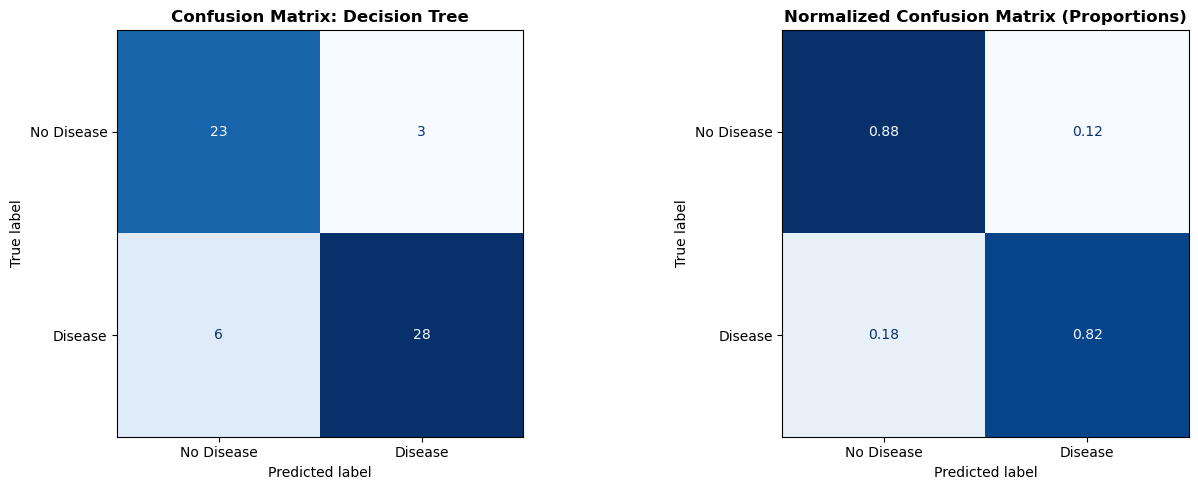

In [138]:
# Now we plot confusion matrix as heatmap (module notebook exact code with improvement)

figure, axes_array = plt.subplots(1, 2, figsize=(14, 5))
# Explanation: We create a side-by-side layout for two plots using 'plt.subplots(1, 2)'. This allows us to compare the raw count of predictions with their normalized (percentage-based) versions in a single window.
# বাংলা ব্যাখ্যা: আমরা 'plt.subplots(1, 2)' ব্যবহার করে পাশাপাশি দুটি প্লট করার জায়গা তৈরি করছি। এর ফলে আমরা একই উইন্ডোতে প্রেডিকশনের আসল সংখ্যা এবং তাদের নরমালাইজড (শতকরা) ভার্সনটি তুলনা করতে পারবো।


# Left: ConfusionMatrixDisplay (sklearn method)
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["No Disease", "Disease"]
)
confusion_matrix_display.plot(ax=axes_array[0], colorbar=False, cmap="Blues")
axes_array[0].set_title("Confusion Matrix: Decision Tree", fontsize=12, fontweight="bold")
# Explanation: On the first subplot, we use 'ConfusionMatrixDisplay' to turn our raw numbers into a heatmap. We label the axes as "No Disease" and "Disease" for clarity, and use 'cmap="Blues"' to color the boxes—darker blue means more samples in that category.
# বাংলা ব্যাখ্যা: প্রথম সাবপ্লটে আমরা 'ConfusionMatrixDisplay' ব্যবহার করে আমাদের সংখ্যাগুলোকে একটি হিটম্যাপে রূপান্তর করছি। স্পষ্ট বোঝার জন্য আমরা লেবেল হিসেবে "No Disease" এবং "Disease" ব্যবহার করছি এবং 'cmap="Blues"' দিয়ে বক্সগুলোকে নীল রঙ করছি—রঙ যত গাঢ় হবে, বুঝতে হবে সেই ঘরে স্যাম্পলের সংখ্যা তত বেশি।


# Right: Normalized confusion matrix (shows proportions)
confusion_matrix_normalized = confusion_matrix_values.astype("float") / confusion_matrix_values.sum(axis=1)[:, np.newaxis]
confusion_matrix_norm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_normalized,
    display_labels=["No Disease", "Disease"]
)
confusion_matrix_norm_display.plot(ax=axes_array[1], colorbar=False, cmap="Blues",
                                   values_format=".2f")
axes_array[1].set_title("Normalized Confusion Matrix (Proportions)", fontsize=12, fontweight="bold")
# Explanation: Here we manually normalize the data by dividing the matrix values by the sum of each row. This gives us 'proportions' (0 to 1) instead of raw counts. We use 'values_format=".2f"' to show only two decimal places, which helps in understanding the percentage accuracy of each class.
# বাংলা ব্যাখ্যা: এখানে আমরা ম্যাট্রিক্সের মানগুলোকে প্রতিটি রো-এর যোগফল দিয়ে ভাগ করে ম্যানুয়ালি ডেটা নরমালাইজ করছি। এটি আমাদের আসল সংখ্যার বদলে অনুপাত বা পার্সেন্টেজ (০ থেকে ১ এর মধ্যে) দেখায়। 'values_format=".2f"' ব্যবহার করে আমরা দশমিকের পর দুই ঘর পর্যন্ত দেখাচ্ছি, যা প্রতিটি ক্লাসের একুরেসি বুঝতে সাহায্য করে।


plt.tight_layout()
plt.show()
# Explanation: We use 'plt.tight_layout()' to ensure that the titles and labels don't overlap, and finally call 'plt.show()' to render both heatmaps on the screen.
# বাংলা ব্যাখ্যা: আমরা 'plt.tight_layout()' ব্যবহার করছি যাতে টাইটেল বা লেবেলগুলো একটার ওপর আরেকটা চড়ে না যায় এবং সবশেষে 'plt.show()' দিয়ে হিটম্যাপ দুটি স্ক্রিনে দেখাচ্ছি।

> 📝 **এই code-এ কী হচ্ছে:** Confusion matrix দুটো ভাবে দেখানো হয়েছে। Left = absolute counts। Right = normalized (row-wise proportion) — imbalanced class-এ more informative।

> ### এই chart কীভাবে observe করব
> - **Top-left (TN)**: Correctly predicted No Disease।
> - **Top-right (FP)**: False Alarm — healthy patient-কে sick বলা।
> - **Bottom-left (FN)**: **Missed disease** — sick patient-কে healthy বলা → most dangerous!
> - **Bottom-right (TP)**: Correctly caught disease.
> - Normalized-এ diagonal-এ 1.0 = perfect model।

> ### এই chart থেকে কী observe করলাম
> - FN কত? → মিস হওয়া disease patient count।
> - FP কত? → Unnecessary alarm count।
> - Diagonal sum বেশি = model ভালো।

> ### Decision
> Medical context-এ FN কম করাই priority — Recall maximize করো।

### ১. মডেলের নির্ভুলতা (Diagonal Accuracy)
হিটম্যাপের কোণাকুণি (Diagonal) বক্সগুলো খেয়াল করো (বামে **২৩** ও **২৮**, ডানে **০.৮৮** ও **০.৮২**)।
* **পর্যবেক্ষণ:** এই নীল বক্সগুলো নির্দেশ করে যে মডেলটি সঠিকভাবে প্রেডিকশন দিয়েছে। অর্থাৎ, ৮৮% ক্ষেত্রে মডেল সঠিকভাবে "রোগ নেই" এবং ৮২% ক্ষেত্রে সঠিকভাবে "রোগ আছে" শনাক্ত করতে পেরেছে। এটি একটি বেশ ভালো স্কোর।

### ২. ফলস অ্যালার্ম (False Positives)
ডান পাশের উপরের বক্সে দেখো **০.১২** বা ১২%।
* **পর্যবেক্ষণ:** এটি হলো 'False Alarm'। অর্থাৎ ১২% মানুষের রোগ ছিল না, কিন্তু মডেল ভুল করে বলেছে যে রোগ আছে। এটি কিছুটা অনাকাঙ্ক্ষিত হলেও খুব বেশি ভয়ের নয়।

### ৩. মিসড কেস বা ঝুঁকি (False Negatives) - অত্যন্ত গুরুত্বপূর্ণ!
বাম পাশের নিচের বক্সে দেখো **৬** এবং ডানে **০.১৮** বা ১৮%।
* **পর্যবেক্ষণ:** এটিই সবচেয়ে গুরুত্বপূর্ণ পয়েন্ট। এর মানে হলো ১৮% মানুষের **আসলে রোগ ছিল**, কিন্তু মডেল ভুল করে বলেছে তাদের **রোগ নেই**।
* **সিদ্ধান্ত:** হার্ট ডিজিজের মতো সেনসিটিভ বিষয়ে ১৮% মিস করা কিছুটা ঝুঁকিপূর্ণ হতে পারে। রিয়েল লাইফে আমাদের এমন মডেল দরকার যেখানে এই সংখ্যাটি আরও অনেক কম হবে।

**সহজ কথায় সারসংক্ষেপ:** মডেলটি মোটামুটি ভালো কাজ করছে, কিন্তু এটি এখনো নিখুঁত নয়। এটি সুস্থ মানুষকে সুস্থ হিসেবে ভালোই চেনে (৮৮%), কিন্তু অসুস্থ রোগীদের শনাক্ত করার ক্ষেত্রে (৮২%) কিছুটা পিছিয়ে আছে। অর্থাৎ, কিছু রোগী মডেলের চোখ ফাঁকি দিয়ে চলে যাচ্ছে।

In [140]:
# Now we compute all classification metrics (module notebook exact code)

accuracy  = accuracy_score(y_test_heart, y_pred_heart)
precision = precision_score(y_test_heart, y_pred_heart)
recall    = recall_score(y_test_heart, y_pred_heart)
f1        = f1_score(y_test_heart, y_pred_heart)
# Explanation: We are using specific functions like 'accuracy_score', 'precision_score', 'recall_score', and 'f1_score' to calculate the four core evaluation metrics. Each function compares the true labels ('y_test_heart') with our model's predictions ('y_pred_heart') to give us a numerical value of performance.
# বাংলা ব্যাখ্যা: আমরা 'accuracy_score', 'precision_score', 'recall_score' এবং 'f1_score' ফাংশনগুলো ব্যবহার করে চারটি মূল ইভ্যালুয়েশন মেট্রিক হিসাব করছি। প্রতিটি ফাংশন আসল লেবেল ('y_test_heart') এবং আমাদের মডেলের দেওয়া প্রেডিকশন ('y_pred_heart') তুলনা করে মডেলের পারফরম্যান্সের একটি গাণিতিক মান দিচ্ছে।


print("Classification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}  -- overall correct predictions")
print(f"  Precision: {precision:.4f}  -- of predicted disease, how many truly have it")
print(f"  Recall:    {recall:.4f}  -- of actual disease, how many were caught")
print(f"  F1 Score:  {f1:.4f}  -- harmonic mean of precision and recall")
print()
# Explanation: We are printing the calculated metrics in a clean format. We use f-strings with ':.4f' to round the numbers to 4 decimal places, making it easier to read the overall correctness, the reliability of positive predictions (Precision), the coverage of actual cases (Recall), and their balance (F1 Score).
# বাংলা ব্যাখ্যা: আমরা হিসাব করা মেট্রিকগুলো একটি সুন্দর ফরম্যাটে প্রিন্ট করছি। এখানে ':.4f' ব্যবহার করে সংখ্যাগুলোকে দশমিকের পর ৪ ঘর পর্যন্ত রাউন্ড করা হয়েছে, যাতে মডেলের সামগ্রিক নির্ভুলতা (Accuracy), পজিটিভ প্রেডিকশনের নির্ভরযোগ্যতা (Precision), আসল রোগী খুঁজে পাওয়ার হার (Recall) এবং তাদের ভারসাম্য (F1 Score) সহজেই পড়া যায়।


print("Full Classification Report:")
print(classification_report(y_test_heart, y_pred_heart,
                             target_names=["No Disease", "Disease"]))
# Explanation: We use the 'classification_report' function to get a comprehensive summary. Instead of just showing the overall score, it breaks down precision, recall, and f1-score for each individual class ('No Disease' and 'Disease'). This helps us see if the model is performing better for one specific group over the other.
# বাংলা ব্যাখ্যা: আমরা 'classification_report' ফাংশনটি ব্যবহার করছি একটি বিস্তারিত সারসংক্ষেপ পাওয়ার জন্য। এটি শুধু সামগ্রিক স্কোর না দেখিয়ে প্রতিটি আলাদা ক্লাসের ('No Disease' এবং 'Disease') জন্য প্রিসিশন, রিকল এবং এফ১-স্কোর আলাদাভাবে দেখায়। এর ফলে আমরা বুঝতে পারি মডেলটি কোনো একটি নির্দিষ্ট ক্লাসের জন্য অন্যটির চেয়ে ভালো কাজ করছে কি না।

Classification Metrics:
  Accuracy:  0.8500  -- overall correct predictions
  Precision: 0.9032  -- of predicted disease, how many truly have it
  Recall:    0.8235  -- of actual disease, how many were caught
  F1 Score:  0.8615  -- harmonic mean of precision and recall

Full Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.88      0.84        26
     Disease       0.90      0.82      0.86        34

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact metrics code। Classification report-এ দুটো class-এর আলাদা precision, recall, F1 দেখা যায়। Support = সেই class-এ test sample count।

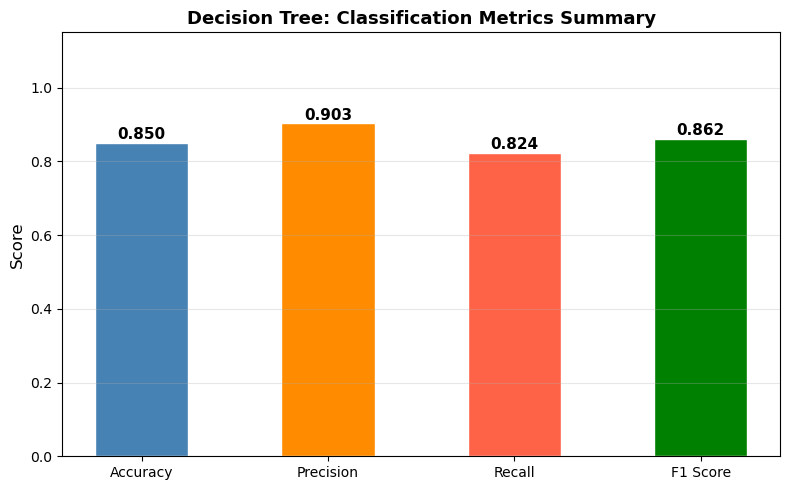

In [126]:
# Now we visualize all metrics as a bar chart

metric_names  = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_values = [accuracy, precision, recall, f1]
metric_colors = ["steelblue", "darkorange", "tomato", "green"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=metric_colors, edgecolor="white", width=0.5)
for bar_item, value in zip(bars, metric_values):
    plt.text(bar_item.get_x() + bar_item.get_width()/2,
             bar_item.get_height() + 0.01,
             f"{value:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.ylim(0, 1.15)
plt.ylabel("Score", fontsize=12)
plt.title("Decision Tree: Classification Metrics Summary", fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** সব metrics একসাথে bar chart-এ দেখানো হয়েছে — quick comparison।

> ### এই chart কীভাবে observe করব
> - প্রতিটি bar একটি metric। সর্বোচ্চ = 1.0 (perfect)।
> - সব bar-ই কাছাকাছি থাকলে model balanced।
> - Recall বেশি কম হলে → অনেক disease miss হচ্ছে।

> ### Decision
> Medical context-এ Recall বাড়ানো priority। Threshold কমিয়ে Recall increase করা যায়।


---
## 11.8–11.9 ROC Curve, AUC, এবং Threshold Interpretation

### Classification Threshold কী? (PDF Slide থেকে)
> Model probability দেয় — 0 থেকে 1।
> Threshold = সেই cutoff যেখানে probability-কে class-এ convert করা হয়।

```
Default threshold = 0.5:
  probability >= 0.5  ->  Class 1 (Disease)
  probability < 0.5   ->  Class 0 (No Disease)
```

**Threshold পরিবর্তনের effect:**
| Threshold | Effect |
|---|---|
| **Low (0.3)** | বেশি positive predict → Recall ↑, Precision ↓ |
| **Default (0.5)** | Balanced |
| **High (0.7+)** | কম positive predict → Precision ↑, Recall ↓ |

### ROC Curve কী?
> **ROC** = Receiver Operating Characteristic
> সব possible threshold-এ TPR vs FPR plot করা।

$$TPR (Recall) = \frac{TP}{TP + FN}$$

$$FPR = \frac{FP}{FP + TN}$$

### ROC Curve Shape-এর অর্থ (PDF Slide থেকে)
| Curve | মানে |
|---|---|
| **Top-left corner-এর কাছে** | Good model — high TPR, low FPR |
| **Diagonal line** | Random model (coin flip) — AUC = 0.5 |
| **Below diagonal** | Broken model — predictions inverted |

### AUC (Area Under the Curve)
> ROC curve-এর নিচের total area = AUC

| AUC Value | মানে |
|---|---|
| **1.0** | Perfect model |
| **0.9+** | Excellent |
| **0.7-0.9** | Good |
| **0.5-0.7** | Fair — marginal |
| **0.5** | Random — useless |
| **< 0.5** | Worse than random |

### 🎯 Interview Topics
- ROC-AUC vs Accuracy কখন কোনটা? → Imbalanced class-এ ROC-AUC বেশি informative
- AUC-এর probabilistic interpretation? → Randomly picked positive sample > randomly picked negative sample-এর probability
- Threshold কীভাবে বেছে নেব? → ROC curve দেখে, business requirement অনুযায়ী
- AUPRC (Precision-Recall Curve)? → Highly imbalanced class-এ ROC-AUC misleading হতে পারে, AUPRC better


In [127]:
# Now we compute predicted probabilities (module notebook exact code)

# predict_proba() returns probabilities for each class
# [:, 1] takes the probability of Class 1 (Disease)
y_probability_heart = heart_tree.predict_proba(X_test_heart)[:, 1]

print("First 10 predicted probabilities (for Class 1 = Disease):")
print(y_probability_heart[:10].round(3))
print()
print("These are NOT 0 or 1 -- they are the model's CONFIDENCE that class = 1")
print(f"Min probability: {y_probability_heart.min():.3f}")
print(f"Max probability: {y_probability_heart.max():.3f}")

First 10 predicted probabilities (for Class 1 = Disease):
[0.875 0.    0.048 0.    0.875 1.    1.    1.    1.    0.   ]

These are NOT 0 or 1 -- they are the model's CONFIDENCE that class = 1
Min probability: 0.000
Max probability: 1.000


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `predict_proba()` code। `predict_proba()` প্রতিটি class-এর probability দেয়। `[:, 1]` দিয়ে Disease class-এর probability নেওয়া হয়েছে।

In [128]:
# Now we compute ROC curve and AUC (module notebook exact code)

false_positive_rates, true_positive_rates, thresholds = roc_curve(
    y_test_heart, y_probability_heart
)
roc_auc_value = auc(false_positive_rates, true_positive_rates)

print(f"AUC: {roc_auc_value:.4f}")
print()
print(f"This means: model correctly ranks a sick patient above a healthy one")
print(f"{roc_auc_value*100:.1f}% of the time!")

AUC: 0.9253

This means: model correctly ranks a sick patient above a healthy one
92.5% of the time!


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact ROC ও AUC computation。 `roc_curve()` সব threshold-এ FPR ও TPR দেয়। `auc()` curve-এর নিচের area calculate করে।

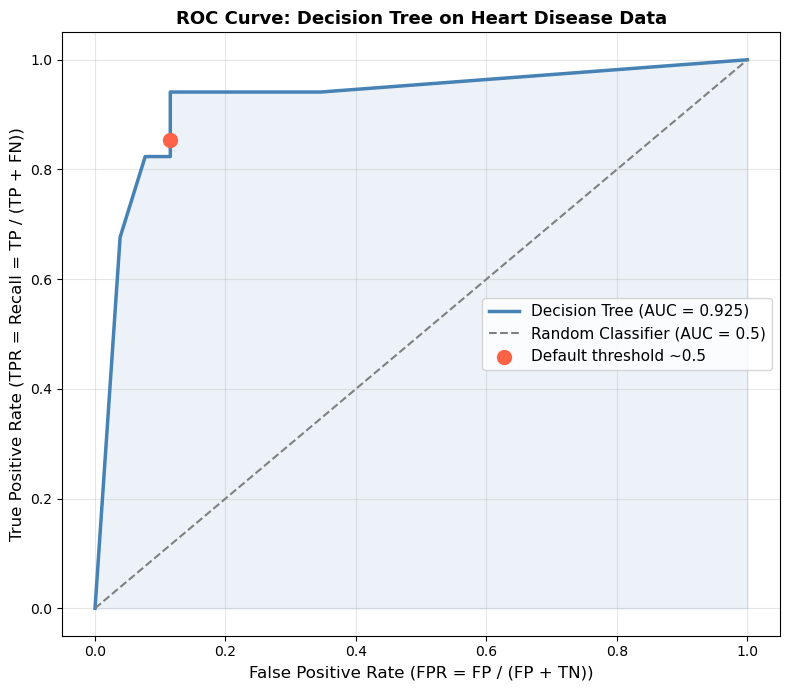

In [129]:
# Now we plot the ROC curve (module notebook exact code + improvement)

plt.figure(figsize=(8, 7))
plt.plot(
    false_positive_rates, true_positive_rates,
    color="steelblue", linewidth=2.5,
    label=f"Decision Tree (AUC = {roc_auc_value:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random Classifier (AUC = 0.5)")
plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.1, color="steelblue")

# Mark the default threshold point (threshold ~= 0.5)
plt.scatter([false_positive_rates[len(thresholds)//2]],
            [true_positive_rates[len(thresholds)//2]],
            color="tomato", s=100, zorder=5, label="Default threshold ~0.5")

plt.xlabel("False Positive Rate (FPR = FP / (FP + TN))", fontsize=12)
plt.ylabel("True Positive Rate (TPR = Recall = TP / (TP + FN))", fontsize=12)
plt.title("ROC Curve: Decision Tree on Heart Disease Data", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact ROC curve plot। Blue curve = model। Gray dashed = random (baseline)। Blue fill = AUC area। Red dot = default threshold point।

> ### এই chart কীভাবে observe করব
> - X-axis = FPR (False Positive Rate, 0-1)।
> - Y-axis = TPR = Recall (True Positive Rate, 0-1)।
> - **Blue curve যত উপরে-বামে** = model তত ভালো।
> - **Gray diagonal** = random classifier (AUC=0.5)।
> - **AUC** = blue area। 1.0=perfect, 0.5=random।
> - প্রতিটি point = একটি specific threshold।

> ### এই chart থেকে কী observe করলাম
> - Curve diagonal-এর উপরে — model random-এর চেয়ে ভালো।
> - AUC value দেখো — 0.7+ হলে model useful।
> - Top-left corner-এ একটি point আছে — ideal threshold সেখানে।

> ### Decision
> Medical context-এ: threshold কমাও → TPR বাড়ে (কম disease miss হয়), কিন্তু FPR-ও বাড়ে।


In [130]:
# Now we show the effect of different thresholds (PDF slide concept)

print("Effect of Changing Decision Threshold:")
print()
print(f"{'Threshold':>12} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 58)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_threshold = (y_probability_heart >= threshold).astype(int)
    acc   = accuracy_score(y_test_heart, y_pred_threshold)
    prec  = precision_score(y_test_heart, y_pred_threshold, zero_division=0)
    rec   = recall_score(y_test_heart, y_pred_threshold, zero_division=0)
    f1_val = f1_score(y_test_heart, y_pred_threshold, zero_division=0)
    print(f"{threshold:>12.1f} {acc:>10.4f} {prec:>12.4f} {rec:>10.4f} {f1_val:>10.4f}")

print()
print("OBSERVE:")
print("  Lower threshold -> Recall increases, Precision decreases")
print("  Higher threshold -> Precision increases, Recall decreases")
print("  Medical: prefer lower threshold (catch more disease, some false alarms OK)")

Effect of Changing Decision Threshold:

   Threshold   Accuracy    Precision     Recall         F1
----------------------------------------------------------
         0.2     0.8500       0.9032     0.8235     0.8615
         0.3     0.8500       0.9032     0.8235     0.8615
         0.4     0.8500       0.9032     0.8235     0.8615
         0.5     0.8500       0.9032     0.8235     0.8615
         0.6     0.8500       0.9032     0.8235     0.8615
         0.7     0.8500       0.9032     0.8235     0.8615
         0.8     0.8500       0.9032     0.8235     0.8615

OBSERVE:
  Lower threshold -> Recall increases, Precision decreases
  Higher threshold -> Precision increases, Recall decreases
  Medical: prefer lower threshold (catch more disease, some false alarms OK)


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর threshold tuning concept code-এ দেখানো হয়েছে। Threshold কমালে Recall বাড়ে (কম disease miss) কিন্তু Precision কমে (বেশি false alarm)। Business context অনুযায়ী threshold বেছে নিতে হবে।

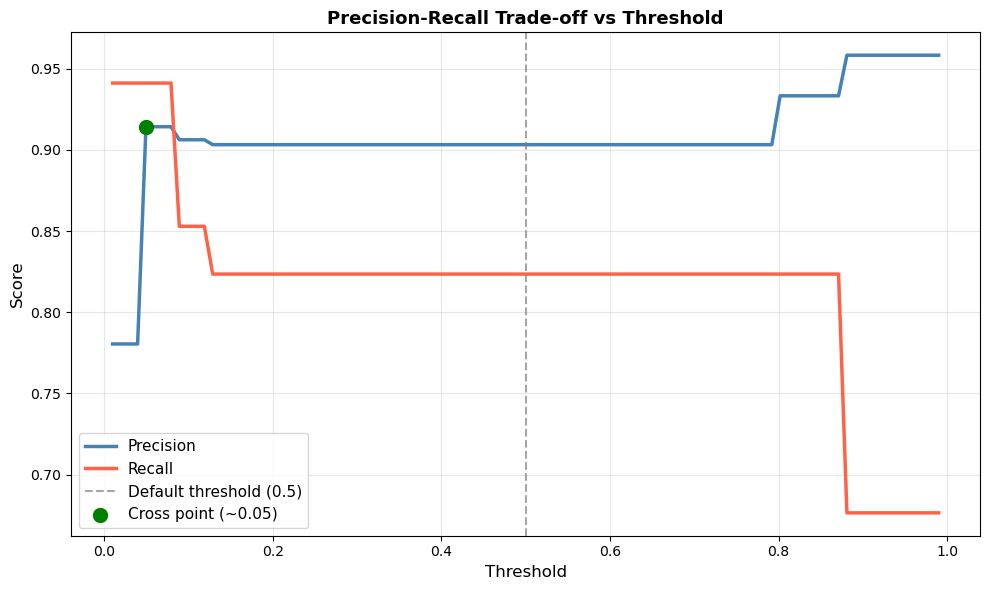

In [131]:
# Now we visualize Precision-Recall tradeoff as threshold changes

threshold_values     = np.linspace(0.01, 0.99, 100)
precision_at_threshold = []
recall_at_threshold    = []

for threshold in threshold_values:
    y_pred_t = (y_probability_heart >= threshold).astype(int)
    if sum(y_pred_t) == 0:
        precision_at_threshold.append(1.0)
        recall_at_threshold.append(0.0)
    else:
        precision_at_threshold.append(precision_score(y_test_heart, y_pred_t, zero_division=1))
        recall_at_threshold.append(recall_score(y_test_heart, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(threshold_values, precision_at_threshold, color="steelblue", linewidth=2.5, label="Precision")
plt.plot(threshold_values, recall_at_threshold,    color="tomato",    linewidth=2.5, label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default threshold (0.5)")

# Mark where precision and recall cross
cross_idx = np.argmin(np.abs(np.array(precision_at_threshold) - np.array(recall_at_threshold)))
plt.scatter([threshold_values[cross_idx]],
            [precision_at_threshold[cross_idx]],
            color="green", s=100, zorder=5, label=f"Cross point (~{threshold_values[cross_idx]:.2f})")

plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Precision-Recall Trade-off vs Threshold", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Precision-Recall trade-off visualization — threshold পরিবর্তনের effect। Blue line (Precision) থ্রেশহোল্ড বাড়ার সাথে বাড়ে। Red line (Recall) থ্রেশহোল্ড বাড়ার সাথে কমে। Cross point = balanced threshold।

> ### এই chart কীভাবে observe করব
> - X-axis = threshold (0 থেকে 1)। Y-axis = metric score।
> - **Blue (Precision)**: threshold বাড়লে বাড়ে।
> - **Red (Recall)**: threshold বাড়লে কমে।
> - **Green dot** = দুটো line cross করার point — balanced threshold।

> ### এই chart থেকে কী observe করলাম
> - Default 0.5-এ Precision ও Recall-এর exact value দেখা যায়।
> - Medical: Recall বেশি গুরুত্বপূর্ণ → threshold কমাও (0.3-0.4 range)।
> - Spam filter: Precision বেশি গুরুত্বপূর্ণ → threshold বাড়াও (0.6-0.7 range)।

> ### Decision
> Business requirement অনুযায়ী threshold বেছে নাও। কখনো blindly 0.5 নয়।


---
## 11.10 Conclusion — Module 11 Complete Summary

### সব Topics একনজরে (PDF Slide থেকে)

| Topic | মূল কথা |
|---|---|
| **Decision Tree** | If-else rules-এর chain। Recursive data splitting। |
| **Root Node** | সবচেয়ে important feature দিয়ে প্রথম split। |
| **Leaf Node** | Final prediction — majority class। |
| **Entropy** | Disorder measure। Range 0-1। 0=pure, 1=maximum impure। |
| **Gini Index** | Misclassification probability। Range 0-0.5। sklearn default। |
| **Information Gain** | Parent impurity - weighted child impurity। Maximize করা হয়। |
| **Overfitting** | Training accuracy >> Test accuracy। Tree memorizes noise। |
| **Pruning** | max_depth, min_samples_leaf দিয়ে complexity limit করা। |
| **Confusion Matrix** | TN, FP, FN, TP — সব prediction breakdown। |
| **Precision** | Predicted positive-এর মধ্যে actually positive কত। |
| **Recall** | Actual positive-এর মধ্যে কত ধরা গেছে। Medical-এ critical। |
| **F1 Score** | Precision ও Recall-এর harmonic mean। Imbalanced-এ best। |
| **ROC Curve** | সব threshold-এ TPR vs FPR plot। |
| **AUC** | ROC curve-এর area। 1=perfect, 0.5=random। |
| **Threshold** | Default 0.5। Business context অনুযায়ী adjust করো। |

### Interview Quick Reference
```
Q: Entropy vs Gini?
A: Both measure impurity. Entropy uses log, Gini uses probability squared.
   sklearn default = Gini (faster). Same result usually.

Q: Decision Tree-এর সবচেয়ে বড় weakness?
A: Overfitting (high variance). Small data change -> completely different tree.

Q: max_depth কীভাবে set করবে?
A: Cross-validation দিয়ে। range(1,15) try করে CV accuracy সর্বোচ্চ যেখানে।

Q: Medical context-এ কোন metric বেশি important?
A: RECALL. FN (missed disease) = most dangerous. Lower threshold to maximize recall.

Q: AUC = 0.5 মানে কী?
A: Model random guess-এর চেয়ে ভালো না। Worse than coin flip!

Q: Feature Importance কীভাবে বের করো?
A: tree.feature_importances_ -- আলাদা sum=1.0 হয়। Root feature সবচেয়ে বেশি।

Q: Decision Tree scale করতে হয় কেন না?
A: Split শুধু ordering দেখে, actual value নয়. Age=30 vs 50 -> just 30<50.

Q: Random Forest কীভাবে Decision Tree-এর উপর বেস?
A: অনেক trees তৈরি করে majority vote নেয়. Individual tree unstable হলেও
   ensemble stable হয় (variance কমে).
```

### Next Module Preview
> **Ensemble Methods (Random Forest, XGBoost)**
> - Random Forest: অনেক Decision Tree-এর majority vote
> - Gradient Boosting: Sequential trees, প্রতিটি আগেরটার error correct করে
> - এগুলো Decision Tree-এর সব weakness সমাধান করে


In [132]:
# FINAL REVIEW: Complete Decision Tree Pipeline

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

print("=" * 60)
print("MODULE 11: COMPLETE DECISION TREE PIPELINE")
print("=" * 60)

# Step 1: Use our heart disease dataset
X_final = heart_dataframe[["age", "chol", "thalach"]]
y_final  = heart_dataframe["target"]

# Step 2: Split
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Step 3: Find best depth with cross-validation
best_depth_final   = None
best_cv_score = 0
for depth in range(1, 10):
    tree_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_mean = cross_val_score(tree_cv, X_tr, y_tr, cv=5).mean()
    if cv_mean > best_cv_score:
        best_cv_score = cv_mean
        best_depth_final   = depth

print(f"\nBest depth (CV): {best_depth_final}, CV Accuracy: {best_cv_score:.4f}")

# Step 4: Train final model
final_tree = DecisionTreeClassifier(max_depth=best_depth_final, random_state=42)
final_tree.fit(X_tr, y_tr)

# Step 5: Evaluate
y_pred_final = final_tree.predict(X_te)
y_prob_final = final_tree.predict_proba(X_te)[:, 1]

print(f"\nFINAL RESULTS:")
print(f"  Accuracy:  {accuracy_score(y_te, y_pred_final):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_te, y_prob_final):.4f}")
print()

TN_f, FP_f, FN_f, TP_f = confusion_matrix(y_te, y_pred_final).ravel()
print(f"  True Positives (TP):  {TP_f}  (Disease correctly caught)")
print(f"  False Negatives (FN): {FN_f}  (Disease MISSED -- minimize this!)")
print()
print(classification_report(y_te, y_pred_final, target_names=["No Disease", "Disease"]))
print("Module 11 Complete!")

MODULE 11: COMPLETE DECISION TREE PIPELINE

Best depth (CV): 4, CV Accuracy: 0.8958

FINAL RESULTS:
  Accuracy:  0.8500
  ROC-AUC:   0.9253

  True Positives (TP):  28  (Disease correctly caught)
  False Negatives (FN): 6  (Disease MISSED -- minimize this!)

              precision    recall  f1-score   support

  No Disease       0.79      0.88      0.84        26
     Disease       0.90      0.82      0.86        34

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

Module 11 Complete!


> 📝 **এই code-এ কী হচ্ছে:** Module 11-এর complete pipeline — CV দিয়ে best depth খোঁজা, train, evaluate। FN highlight করা হয়েছে — medical context-এ এটাই সবচেয়ে important metric।

---